# 10 — OpenCV Difference Maps

This notebook generates standardized spatial diagnostics for the complete OpenCV Telea restoration experiment.

It extends the earlier difference-map workflow across:

- the canonical controlled-damage dataset;
- damage-size sensitivity cases;
- mask-robustness cases;
- synthetic-degradation cases.

The notebook produces:

- clean-versus-damaged absolute-error maps;
- clean-versus-restored absolute-error maps;
- signed restoration-improvement maps;
- masked spatial diagnostics;
- damage-mask overlays;
- painting-content bounding-box overlays;
- mask bounding-box overlays;
- mask-boundary overlays;
- fixed and comparable visualization scales;
- machine-readable manifests for later XAI analysis and case-report generation.

The signed improvement map is defined as:

`damaged absolute error - restored absolute error`

Therefore:

- positive values indicate that restoration reduced reference error;
- negative values indicate that restoration increased reference error;
- zero values indicate no change.

The notebook preserves the useful metric-driven case-selection and diagnostic logic from the original difference-map notebook while extending it to the complete OpenCV experiment. Dataset-specific restoration metadata and identifiers are retained so that canonical, sensitivity, robustness, and degradation cases are not incorrectly merged with one another.

In [39]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Configuration path:", CONFIG_PATH)

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Source directory not found: {SRC_DIR}"
    )

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Experiment configuration not found: {CONFIG_PATH}"
    )

print("Notebook environment setup passed.")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Configuration path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Notebook environment setup passed.


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from restoration_eval.error_maps import (
    apply_mask_to_map,
    compute_absolute_error_map,
    compute_error_map_summary,
    compute_signed_improvement_map,
    load_mask_bool,
    load_rgb_array,
)

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})

processed_metadata_dir = (
    PROJECT_ROOT
    / paths_cfg["processed_metadata_dir"]
)

metrics_dir = (
    PROJECT_ROOT
    / paths_cfg["metrics_dir"]
)

figures_dir = (
    PROJECT_ROOT
    / paths_cfg["figures_dir"]
)

metrics_dir.mkdir(
    parents=True,
    exist_ok=True,
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

target_size = (
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or config.get("experiment", {}).get("image_size")
    or 768
)

mask_bbox_margin = 8
boundary_width = 3

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)

restoration_metadata_paths = {
    "canonical": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea.csv"
    ),
    "damage_size": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_damage_size.csv"
    ),
    "mask_robustness": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_mask_robustness.csv"
    ),
    "synthetic": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_synthetic.csv"
    ),
}

classical_metrics_path = (
    metrics_dir
    / "metrics_classical_opencv_telea_all.csv"
)

error_map_output_dir = (
    figures_dir
    / "error_maps"
    / "opencv_telea"
)

error_map_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print("Processed metadata directory:", processed_metadata_dir)
print("Metrics directory:", metrics_dir)
print("Figures directory:", figures_dir)
print("Error-map output directory:", error_map_output_dir)
print("Target image size:", target_size)
print("Mask bbox margin:", mask_bbox_margin)
print("Boundary width:", boundary_width)

print("\nExpected OpenCV datasets:")

for dataset_name, metadata_path in restoration_metadata_paths.items():
    print(f"  {dataset_name:18s}: {metadata_path}")

Processed metadata directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata
Metrics directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics
Figures directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures
Error-map output directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\opencv_telea
Target image size: 768
Mask bbox margin: 8
Boundary width: 3

Expected OpenCV datasets:
  canonical         : D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea.csv
  damage_size       : D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea_damage_size.csv
  mask_robustness   : D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea_mask_robustness.csv
  synthetic         : D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_te

In [41]:
required_input_paths = {
    "processed_painting_metadata": (
        processed_metadata_path
    ),
    "unified_classical_metrics": (
        classical_metrics_path
    ),
}

for dataset_name, metadata_path in restoration_metadata_paths.items():
    required_input_paths[
        f"restoration_metadata_{dataset_name}"
    ] = metadata_path

input_inventory_df = pd.DataFrame(
    [
        {
            "input_name": input_name,
            "input_path": str(input_path),
            "exists": input_path.exists(),
            "file_size_bytes": (
                input_path.stat().st_size
                if input_path.exists()
                else 0
            ),
        }
        for input_name, input_path
        in required_input_paths.items()
    ]
)

display(input_inventory_df)

missing_inputs = (
    input_inventory_df.loc[
        ~input_inventory_df["exists"],
        [
            "input_name",
            "input_path",
        ],
    ]
    .copy()
)

if not missing_inputs.empty:
    display(missing_inputs)

    raise FileNotFoundError(
        "One or more required Notebook 10 inputs are missing."
    )

empty_inputs = (
    input_inventory_df.loc[
        input_inventory_df["file_size_bytes"].eq(0),
        [
            "input_name",
            "input_path",
        ],
    ]
    .copy()
)

if not empty_inputs.empty:
    display(empty_inputs)

    raise ValueError(
        "One or more required Notebook 10 inputs are empty."
    )

expected_dataset_names = set(
    restoration_metadata_paths.keys()
)

if expected_dataset_names != {
    "canonical",
    "damage_size",
    "mask_robustness",
    "synthetic",
}:
    raise ValueError(
        "Notebook 10 dataset scope is incomplete or unexpected: "
        f"{sorted(expected_dataset_names)}"
    )

print(
    "Input discovery passed for all four "
    "OpenCV restoration datasets."
)

,input_name,input_path,exists,file_size_bytes
0,processed_painting_metadata,D:\Masters\FH\Thesis\painting-restoration-eval...,True,30450
1,unified_classical_metrics,D:\Masters\FH\Thesis\painting-restoration-eval...,True,932135
2,restoration_metadata_canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,150736
3,restoration_metadata_damage_size,D:\Masters\FH\Thesis\painting-restoration-eval...,True,26210
4,restoration_metadata_mask_robustness,D:\Masters\FH\Thesis\painting-restoration-eval...,True,55823
5,restoration_metadata_synthetic,D:\Masters\FH\Thesis\painting-restoration-eval...,True,37171


Input discovery passed for all four OpenCV restoration datasets.


In [42]:
processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

classical_metrics_df = pd.read_csv(
    classical_metrics_path
)

restoration_metadata = {}

for dataset_name, metadata_path in (
    restoration_metadata_paths.items()
):
    dataset_df = pd.read_csv(
        metadata_path
    ).copy()

    dataset_df["dataset_name"] = dataset_name

    restoration_metadata[
        dataset_name
    ] = dataset_df

print(
    f"Processed painting metadata: "
    f"{len(processed_metadata_df):,} rows"
)

print(
    f"Unified classical metrics: "
    f"{len(classical_metrics_df):,} rows"
)

print("\nRestoration cases by dataset:")

restoration_case_counts = []

for dataset_name, dataset_df in (
    restoration_metadata.items()
):
    restoration_case_counts.append(
        {
            "dataset_name": dataset_name,
            "restoration_cases": len(dataset_df),
            "unique_case_ids": (
                dataset_df["case_id"].nunique()
                if "case_id" in dataset_df.columns
                else np.nan
            ),
            "columns": len(dataset_df.columns),
        }
    )

restoration_case_counts_df = pd.DataFrame(
    restoration_case_counts
)

display(restoration_case_counts_df)

total_restoration_cases = int(
    restoration_case_counts_df[
        "restoration_cases"
    ].sum()
)

print(
    f"Total OpenCV restoration cases: "
    f"{total_restoration_cases:,}"
)

Processed painting metadata: 50 rows
Unified classical metrics: 2,260 rows

Restoration cases by dataset:


,dataset_name,restoration_cases,unique_case_ids,columns
0,canonical,250,250,23
1,damage_size,35,35,23
2,mask_robustness,75,75,23
3,synthetic,50,50,23


Total OpenCV restoration cases: 410


In [43]:
required_metric_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "evaluation_region",
]

missing_metric_columns = [
    column
    for column in required_metric_columns
    if column not in classical_metrics_df.columns
]

if missing_metric_columns:
    raise ValueError(
        "Unified classical metrics are missing required columns: "
        f"{missing_metric_columns}"
    )

metric_dataset_names = set(
    classical_metrics_df[
        "dataset_name"
    ]
    .dropna()
    .astype(str)
    .unique()
)

restoration_dataset_names = set(
    restoration_metadata.keys()
)

print(
    "Restoration datasets:",
    sorted(restoration_dataset_names),
)

print(
    "Metric datasets:",
    sorted(metric_dataset_names),
)

if metric_dataset_names != restoration_dataset_names:
    raise ValueError(
        "Dataset mismatch between restoration metadata "
        "and Notebook 09 metrics.\n"
        f"Restoration datasets: "
        f"{sorted(restoration_dataset_names)}\n"
        f"Metric datasets: "
        f"{sorted(metric_dataset_names)}"
    )

restoration_scope_rows = []

for dataset_name, restoration_df in (
    restoration_metadata.items()
):
    metric_df = classical_metrics_df.loc[
        classical_metrics_df[
            "dataset_name"
        ].astype(str).eq(dataset_name)
    ]

    restoration_case_ids = set(
        restoration_df[
            "case_id"
        ]
        .dropna()
        .astype(str)
    )

    metric_case_ids = set(
        metric_df[
            "case_id"
        ]
        .dropna()
        .astype(str)
    )

    restoration_scope_rows.append(
        {
            "dataset_name": dataset_name,
            "restoration_rows": len(restoration_df),
            "restoration_unique_cases": (
                len(restoration_case_ids)
            ),
            "metric_rows": len(metric_df),
            "metric_unique_cases": (
                len(metric_case_ids)
            ),
            "missing_from_metrics": len(
                restoration_case_ids
                - metric_case_ids
            ),
            "missing_from_restoration": len(
                metric_case_ids
                - restoration_case_ids
            ),
        }
    )

scope_validation_df = pd.DataFrame(
    restoration_scope_rows
)

display(scope_validation_df)

invalid_scope_rows = scope_validation_df.loc[
    scope_validation_df[
        [
            "missing_from_metrics",
            "missing_from_restoration",
        ]
    ]
    .ne(0)
    .any(axis=1)
]

if not invalid_scope_rows.empty:
    display(invalid_scope_rows)

    raise ValueError(
        "Notebook 10 case scope does not match "
        "Notebook 09 metric scope."
    )

print(
    "Dataset and case scope matches Notebook 09 "
    "for all four OpenCV datasets."
)

Restoration datasets: ['canonical', 'damage_size', 'mask_robustness', 'synthetic']
Metric datasets: ['canonical', 'damage_size', 'mask_robustness', 'synthetic']


,dataset_name,restoration_rows,restoration_unique_cases,metric_rows,metric_unique_cases,missing_from_metrics,missing_from_restoration
0,canonical,250,250,1300,250,0,0
1,damage_size,35,35,210,35,0,0
2,mask_robustness,75,75,450,75,0,0
3,synthetic,50,50,300,50,0,0


Dataset and case scope matches Notebook 09 for all four OpenCV datasets.


In [44]:
schema_inventory_rows = []

input_tables = {
    "processed_metadata": processed_metadata_df,
    "classical_metrics_all": classical_metrics_df,
    **{
        f"restoration_{dataset_name}": dataset_df
        for dataset_name, dataset_df
        in restoration_metadata.items()
    },
}

for table_name, table_df in input_tables.items():
    schema_inventory_rows.append(
        {
            "table_name": table_name,
            "rows": len(table_df),
            "columns": len(table_df.columns),
            "duplicate_column_names": int(
                table_df.columns.duplicated().sum()
            ),
            "unique_case_ids": (
                table_df["case_id"].nunique(dropna=True)
                if "case_id" in table_df.columns
                else np.nan
            ),
            "unique_painting_ids": (
                table_df["painting_id"].nunique(dropna=True)
                if "painting_id" in table_df.columns
                else np.nan
            ),
        }
    )

schema_inventory_df = pd.DataFrame(
    schema_inventory_rows
)

display(schema_inventory_df)

for table_name, table_df in input_tables.items():
    print(f"\n{'=' * 80}")
    print(table_name)
    print(f"{'=' * 80}")
    print(table_df.columns.tolist())

if schema_inventory_df[
    "duplicate_column_names"
].gt(0).any():
    raise ValueError(
        "At least one input table contains duplicate column names."
    )

print("\nSchema inventory completed.")

,table_name,rows,columns,duplicate_column_names,unique_case_ids,unique_painting_ids
0,processed_metadata,50,47,0,NaN,50
1,classical_metrics_all,2260,38,0,410.0,50
2,restoration_canonical,250,23,0,250.0,50
3,restoration_damage_size,35,23,0,35.0,5
4,restoration_mask_robustness,75,23,0,75.0,5
5,restoration_synthetic,50,23,0,50.0,5



processed_metadata
['painting_id', 'category', 'title', 'artist', 'date', 'style_or_period', 'medium', 'source', 'source_url', 'license', 'filename', 'original_width', 'original_height', 'selection_reason', 'visual_complexity_note', 'status', 'notes', 'raw_filename', 'raw_image_path', 'processed_filename', 'processed_path', 'processed_width', 'processed_height', 'target_size', 'resize_scale', 'resized_width', 'resized_height', 'pad_left', 'pad_top', 'pad_right', 'pad_bottom', 'padding_color_r', 'padding_color_g', 'padding_color_b', 'content_x_min', 'content_y_min', 'content_x_max', 'content_y_max', 'content_width', 'content_height', 'preprocessing_method', 'content_area_pixels', 'canvas_area_pixels', 'content_area_percentage', 'padding_area_pixels', 'padding_area_percentage', 'aspect_orientation']

classical_metrics_all
['dataset_name', 'case_id', 'painting_id', 'category', 'title', 'mask_id', 'mask_type', 'model_name', 'evaluation_region', 'region_pixel_count', 'region_x_min', 'regio

In [45]:
required_restoration_columns = [
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
    "model_name",
]

optional_restoration_columns = [
    "mask_id",
    "mask_type",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_bbox",
]

contract_rows = []

for dataset_name, dataset_df in (
    restoration_metadata.items()
):
    missing_required = [
        column
        for column in required_restoration_columns
        if column not in dataset_df.columns
    ]

    present_optional = [
        column
        for column in optional_restoration_columns
        if column in dataset_df.columns
    ]

    contract_rows.append(
        {
            "dataset_name": dataset_name,
            "rows": len(dataset_df),
            "required_columns_present": (
                len(missing_required) == 0
            ),
            "missing_required_columns": (
                ", ".join(missing_required)
            ),
            "optional_columns_present": (
                ", ".join(present_optional)
            ),
        }
    )

restoration_contract_df = pd.DataFrame(
    contract_rows
)

display(restoration_contract_df)

invalid_contract_df = restoration_contract_df.loc[
    ~restoration_contract_df[
        "required_columns_present"
    ]
]

if not invalid_contract_df.empty:
    display(invalid_contract_df)

    raise ValueError(
        "At least one restoration dataset does not satisfy "
        "the minimum spatial-diagnostic contract."
    )

print(
    "All four restoration datasets satisfy the minimum "
    "difference-map contract."
)

,dataset_name,rows,required_columns_present,missing_required_columns,optional_columns_present
0,canonical,250,True,,
1,damage_size,35,True,,
2,mask_robustness,75,True,,
3,synthetic,50,True,,


All four restoration datasets satisfy the minimum difference-map contract.


In [46]:
identifier_audit_rows = []

for dataset_name, dataset_df in (
    restoration_metadata.items()
):
    case_id_series = (
        dataset_df["case_id"]
        .astype("string")
    )

    painting_id_series = (
        dataset_df["painting_id"]
        .astype("string")
    )

    duplicate_case_rows = int(
        dataset_df.duplicated(
            subset=["case_id"],
            keep=False,
        ).sum()
    )

    duplicate_case_painting_rows = int(
        dataset_df.duplicated(
            subset=[
                "case_id",
                "painting_id",
            ],
            keep=False,
        ).sum()
    )

    identifier_audit_rows.append(
        {
            "dataset_name": dataset_name,
            "rows": len(dataset_df),
            "missing_case_id": int(
                case_id_series.isna().sum()
            ),
            "missing_painting_id": int(
                painting_id_series.isna().sum()
            ),
            "unique_case_ids": int(
                case_id_series.nunique(dropna=True)
            ),
            "duplicate_case_rows": (
                duplicate_case_rows
            ),
            "duplicate_case_painting_rows": (
                duplicate_case_painting_rows
            ),
        }
    )

identifier_audit_df = pd.DataFrame(
    identifier_audit_rows
)

display(identifier_audit_df)

invalid_identifier_df = identifier_audit_df.loc[
    identifier_audit_df[
        [
            "missing_case_id",
            "missing_painting_id",
            "duplicate_case_rows",
            "duplicate_case_painting_rows",
        ]
    ]
    .ne(0)
    .any(axis=1)
]

if not invalid_identifier_df.empty:
    display(invalid_identifier_df)

    raise ValueError(
        "Restoration identifiers are missing or duplicated."
    )

print(
    "Restoration case identifiers are complete and unique "
    "within every dataset."
)

,dataset_name,rows,missing_case_id,missing_painting_id,unique_case_ids,duplicate_case_rows,duplicate_case_painting_rows
0,canonical,250,0,0,250,0,0
1,damage_size,35,0,0,35,0,0
2,mask_robustness,75,0,0,75,0,0
3,synthetic,50,0,0,50,0,0


Restoration case identifiers are complete and unique within every dataset.


In [48]:
path_columns = [
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
]


def resolve_project_path(path_value):
    """
    Resolve a metadata path against the project repository.

    Metadata paths may be:
    - absolute paths;
    - paths relative to PROJECT_ROOT;
    - paths prefixed with the repository directory name;
    - paths containing Windows or POSIX separators.
    """
    if pd.isna(path_value):
        return None

    path_text = str(path_value).strip()

    if not path_text:
        return None

    # Normalize separators so metadata remains portable
    # between Windows and POSIX environments.
    normalized_text = path_text.replace("\\", "/")
    raw_path = Path(normalized_text)

    candidate_paths = []

    # 1. Already absolute.
    if raw_path.is_absolute():
        candidate_paths.append(raw_path)

    # 2. Relative to the repository root.
    candidate_paths.append(
        PROJECT_ROOT / raw_path
    )

    # 3. Relative to the current working directory.
    candidate_paths.append(
        Path.cwd().resolve() / raw_path
    )

    # 4. Metadata may include the repository folder itself,
    # for example:
    # painting_restoration_eval/data/...
    if (
        raw_path.parts
        and raw_path.parts[0] == PROJECT_ROOT.name
    ):
        candidate_paths.append(
            PROJECT_ROOT.parent / raw_path
        )

        candidate_paths.append(
            PROJECT_ROOT.joinpath(
                *raw_path.parts[1:]
            )
        )

    # Remove duplicate candidates while preserving order.
    unique_candidates = []

    for candidate_path in candidate_paths:
        resolved_candidate = (
            candidate_path
            .expanduser()
            .resolve()
        )

        if resolved_candidate not in unique_candidates:
            unique_candidates.append(
                resolved_candidate
            )

    for candidate_path in unique_candidates:
        if candidate_path.exists():
            return candidate_path

    # Return the normal project-relative candidate for
    # useful diagnostics when nothing exists.
    return (
        unique_candidates[0]
        if unique_candidates
        else None
    )


path_audit_rows = []
missing_path_examples = []

for dataset_name, dataset_df in (
    restoration_metadata.items()
):
    for path_column in path_columns:
        raw_paths = (
            dataset_df[path_column]
            .astype("string")
        )

        missing_values = int(
            raw_paths.isna().sum()
        )

        blank_values = int(
            raw_paths
            .fillna("")
            .str.strip()
            .eq("")
            .sum()
        )

        resolved_paths = raw_paths.apply(
            resolve_project_path
        )

        existing_files = resolved_paths.apply(
            lambda path: (
                path is not None
                and path.is_file()
            )
        )

        missing_mask = ~existing_files

        path_audit_rows.append(
            {
                "dataset_name": dataset_name,
                "path_column": path_column,
                "rows": len(dataset_df),
                "missing_values": missing_values,
                "blank_values": blank_values,
                "existing_files": int(
                    existing_files.sum()
                ),
                "missing_files": int(
                    missing_mask.sum()
                ),
            }
        )

        if missing_mask.any():
            missing_indices = (
                dataset_df.index[
                    missing_mask
                ][:3]
            )

            for row_index in missing_indices:
                missing_path_examples.append(
                    {
                        "dataset_name": dataset_name,
                        "path_column": path_column,
                        "case_id": dataset_df.at[
                            row_index,
                            "case_id",
                        ],
                        "stored_path": dataset_df.at[
                            row_index,
                            path_column,
                        ],
                        "resolved_path": str(
                            resolved_paths.at[
                                row_index
                            ]
                        ),
                    }
                )


path_audit_df = pd.DataFrame(
    path_audit_rows
)

display(path_audit_df)

invalid_path_rows = path_audit_df.loc[
    path_audit_df[
        [
            "missing_values",
            "blank_values",
            "missing_files",
        ]
    ]
    .ne(0)
    .any(axis=1)
]

if not invalid_path_rows.empty:
    display(invalid_path_rows)

    missing_path_examples_df = pd.DataFrame(
        missing_path_examples
    )

    if not missing_path_examples_df.empty:
        print(
            "\nExample unresolved paths:"
        )

        display(
            missing_path_examples_df
        )

    raise FileNotFoundError(
        "One or more restoration image paths could not "
        "be resolved relative to the project repository."
    )

print(
    "All clean, damaged, mask, and restored image files "
    "exist for every OpenCV dataset."
)

,dataset_name,path_column,rows,missing_values,blank_values,existing_files,missing_files
0,canonical,clean_path,250,0,0,250,0
1,canonical,damaged_path,250,0,0,250,0
2,canonical,mask_path,250,0,0,250,0
3,canonical,restored_path,250,0,0,250,0
4,damage_size,clean_path,35,0,0,35,0
5,damage_size,damaged_path,35,0,0,35,0
6,damage_size,mask_path,35,0,0,35,0
7,damage_size,restored_path,35,0,0,35,0
8,mask_robustness,clean_path,75,0,0,75,0
9,mask_robustness,damaged_path,75,0,0,75,0


All clean, damaged, mask, and restored image files exist for every OpenCV dataset.


In [49]:
normalized_restoration_frames = []

for dataset_name, dataset_df in (
    restoration_metadata.items()
):
    normalized_df = dataset_df.copy()

    normalized_df["dataset_name"] = dataset_name

    for path_column in path_columns:
        normalized_df[path_column] = (
            normalized_df[path_column]
            .apply(resolve_project_path)
            .apply(
                lambda path: (
                    str(path)
                    if path is not None
                    else pd.NA
                )
            )
        )

    normalized_restoration_frames.append(
        normalized_df
    )

restoration_cases_df = pd.concat(
    normalized_restoration_frames,
    ignore_index=True,
    sort=False,
)

restoration_cases_df["case_id"] = (
    restoration_cases_df["case_id"]
    .astype("string")
)

restoration_cases_df["painting_id"] = (
    restoration_cases_df["painting_id"]
    .astype("string")
)

restoration_cases_df["dataset_name"] = (
    restoration_cases_df["dataset_name"]
    .astype("string")
)

display(
    restoration_cases_df[
        [
            "dataset_name",
            "case_id",
            "painting_id",
            "model_name",
            "clean_path",
            "mask_path",
            "damaged_path",
            "restored_path",
        ]
    ].head()
)

print(
    "Combined restoration rows:",
    f"{len(restoration_cases_df):,}",
)

print(
    "Combined unique dataset-case keys:",
    restoration_cases_df[
        [
            "dataset_name",
            "case_id",
        ]
    ]
    .drop_duplicates()
    .shape[0],
)

duplicate_global_keys = (
    restoration_cases_df.duplicated(
        subset=[
            "dataset_name",
            "case_id",
        ],
        keep=False,
    )
)

if duplicate_global_keys.any():
    display(
        restoration_cases_df.loc[
            duplicate_global_keys,
            [
                "dataset_name",
                "case_id",
                "painting_id",
                "model_name",
            ],
        ].sort_values(
            [
                "dataset_name",
                "case_id",
            ]
        )
    )

    raise ValueError(
        "Duplicate dataset-case keys exist in the "
        "combined restoration metadata."
    )

if len(restoration_cases_df) != total_restoration_cases:
    raise ValueError(
        "Combined restoration row count changed unexpectedly.\n"
        f"Expected: {total_restoration_cases:,}\n"
        f"Observed: {len(restoration_cases_df):,}"
    )

print(
    "Unified restoration table contains exactly one row "
    "per dataset-case key."
)

,dataset_name,case_id,painting_id,model_name,clean_path,mask_path,damaged_path,restored_path
0,canonical,p001_loss_large,p001,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical,p001_loss_small,p001,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,canonical,p001_mixed_damage,p001,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,canonical,p001_scratch_thin,p001,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,canonical,p001_zero_control,p001,opencv_telea,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Combined restoration rows: 410
Combined unique dataset-case keys: 410
Unified restoration table contains exactly one row per dataset-case key.


In [50]:
case_metadata_candidates = [
    "mask_id",
    "mask_type",
    "category",
    "title",
    "damage_fraction",
    "mask_fraction",
    "mask_area_fraction",
    "damage_level",
    "damage_size",
    "perturbation_type",
    "robustness_variant",
    "synthetic_degradation_type",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_bbox",
]

available_case_metadata_columns = [
    column
    for column in case_metadata_candidates
    if column in classical_metrics_df.columns
]

print(
    "Available case-level metadata columns from metrics:",
    available_case_metadata_columns,
)

metric_case_key_columns = [
    "dataset_name",
    "case_id",
]

metric_case_metadata_source_df = (
    classical_metrics_df[
        metric_case_key_columns
        + available_case_metadata_columns
    ]
    .copy()
)

non_invariant_rows = []

for metadata_column in available_case_metadata_columns:
    value_counts = (
        metric_case_metadata_source_df
        .groupby(
            metric_case_key_columns,
            dropna=False,
        )[metadata_column]
        .nunique(dropna=True)
        .reset_index(
            name="unique_non_null_values"
        )
    )

    invalid_values = value_counts.loc[
        value_counts[
            "unique_non_null_values"
        ].gt(1)
    ]

    if not invalid_values.empty:
        invalid_values[
            "metadata_column"
        ] = metadata_column

        non_invariant_rows.append(
            invalid_values
        )

if non_invariant_rows:
    non_invariant_case_metadata_df = pd.concat(
        non_invariant_rows,
        ignore_index=True,
    )

    display(
        non_invariant_case_metadata_df
    )

    raise ValueError(
        "One or more supposed case-level metadata columns "
        "vary across evaluation-region rows."
    )

metric_case_metadata_df = (
    metric_case_metadata_source_df
    .sort_values(
        metric_case_key_columns
    )
    .groupby(
        metric_case_key_columns,
        as_index=False,
        dropna=False,
    )
    .first()
)

display(
    metric_case_metadata_df.head()
)

print(
    "Metric-derived case metadata rows:",
    f"{len(metric_case_metadata_df):,}",
)

if len(metric_case_metadata_df) != total_restoration_cases:
    raise ValueError(
        "Metric-derived case metadata does not contain "
        "exactly one row per restoration case.\n"
        f"Expected: {total_restoration_cases:,}\n"
        f"Observed: {len(metric_case_metadata_df):,}"
    )

print(
    "Metric metadata successfully reduced to one invariant "
    "row per OpenCV case."
)

Available case-level metadata columns from metrics: ['mask_id', 'mask_type', 'category', 'title']


,dataset_name,case_id,mask_id,mask_type,category,title
0,canonical,p001_loss_large,NaN,NaN,portrait_figure,Juan de Pareja
1,canonical,p001_loss_small,NaN,NaN,portrait_figure,Juan de Pareja
2,canonical,p001_mixed_damage,NaN,NaN,portrait_figure,Juan de Pareja
3,canonical,p001_scratch_thin,NaN,NaN,portrait_figure,Juan de Pareja
4,canonical,p001_zero_control,NaN,NaN,portrait_figure,Juan de Pareja


Metric-derived case metadata rows: 410
Metric metadata successfully reduced to one invariant row per OpenCV case.


In [51]:
painting_metadata_columns = [
    column
    for column in [
        "painting_id",
        "category",
        "title",
    ]
    if column in processed_metadata_df.columns
]

painting_metadata_lookup_df = (
    processed_metadata_df[
        painting_metadata_columns
    ]
    .copy()
)

if painting_metadata_lookup_df[
    "painting_id"
].duplicated().any():
    duplicate_paintings_df = (
        painting_metadata_lookup_df.loc[
            painting_metadata_lookup_df[
                "painting_id"
            ].duplicated(
                keep=False
            )
        ]
        .sort_values("painting_id")
    )

    display(duplicate_paintings_df)

    raise ValueError(
        "Processed painting metadata contains duplicate "
        "painting_id values."
    )

case_manifest_df = restoration_cases_df.merge(
    metric_case_metadata_df,
    on=[
        "dataset_name",
        "case_id",
    ],
    how="left",
    validate="one_to_one",
    suffixes=(
        "",
        "_metric",
    ),
)

case_manifest_df = case_manifest_df.merge(
    painting_metadata_lookup_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
    suffixes=(
        "",
        "_painting",
    ),
)

for base_column in [
    "category",
    "title",
    "mask_id",
    "mask_type",
]:
    related_columns = [
        column
        for column in [
            base_column,
            f"{base_column}_metric",
            f"{base_column}_painting",
        ]
        if column in case_manifest_df.columns
    ]

    if not related_columns:
        continue

    coalesced_series = pd.Series(
        pd.NA,
        index=case_manifest_df.index,
        dtype="object",
    )

    for related_column in related_columns:
        coalesced_series = (
            coalesced_series.fillna(
                case_manifest_df[
                    related_column
                ]
            )
        )

    case_manifest_df[
        base_column
    ] = coalesced_series

columns_to_drop = [
    column
    for column in case_manifest_df.columns
    if column.endswith("_metric")
    or column.endswith("_painting")
]

case_manifest_df = case_manifest_df.drop(
    columns=columns_to_drop
)

print(
    "Unified manifest rows:",
    f"{len(case_manifest_df):,}",
)

display(
    case_manifest_df[
        [
            column
            for column in [
                "dataset_name",
                "case_id",
                "painting_id",
                "category",
                "title",
                "mask_id",
                "mask_type",
                "model_name",
            ]
            if column in case_manifest_df.columns
        ]
    ].head(10)
)

Unified manifest rows: 410


E:\HFCache\tmp\ipykernel_23752\1936024320.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coalesced_series.fillna(
E:\HFCache\tmp\ipykernel_23752\1936024320.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coalesced_series.fillna(


,dataset_name,case_id,painting_id,category,title,mask_id,mask_type,model_name
0,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,NaN,NaN,opencv_telea
1,canonical,p001_loss_small,p001,portrait_figure,Juan de Pareja,NaN,NaN,opencv_telea
2,canonical,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,NaN,NaN,opencv_telea
3,canonical,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,NaN,NaN,opencv_telea
4,canonical,p001_zero_control,p001,portrait_figure,Juan de Pareja,NaN,NaN,opencv_telea
5,canonical,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),NaN,NaN,opencv_telea
6,canonical,p002_loss_small,p002,portrait_figure,Madame X (Madame Pierre Gautreau),NaN,NaN,opencv_telea
7,canonical,p002_mixed_damage,p002,portrait_figure,Madame X (Madame Pierre Gautreau),NaN,NaN,opencv_telea
8,canonical,p002_scratch_thin,p002,portrait_figure,Madame X (Madame Pierre Gautreau),NaN,NaN,opencv_telea
9,canonical,p002_zero_control,p002,portrait_figure,Madame X (Madame Pierre Gautreau),NaN,NaN,opencv_telea


In [52]:
if len(case_manifest_df) != total_restoration_cases:
    raise ValueError(
        "Manifest row count changed during metadata enrichment.\n"
        f"Expected: {total_restoration_cases:,}\n"
        f"Observed: {len(case_manifest_df):,}"
    )

if case_manifest_df.duplicated(
    subset=[
        "dataset_name",
        "case_id",
    ]
).any():
    raise ValueError(
        "Duplicate dataset-case keys appeared after enrichment."
    )

required_manifest_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
]

missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in case_manifest_df.columns
]

if missing_manifest_columns:
    raise ValueError(
        "Unified case manifest is missing required columns: "
        f"{missing_manifest_columns}"
    )

manifest_completeness_rows = []

report_columns = [
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
]

for dataset_name, dataset_df in (
    case_manifest_df.groupby(
        "dataset_name",
        sort=True,
    )
):
    completeness_row = {
        "dataset_name": dataset_name,
        "cases": len(dataset_df),
    }

    for column in report_columns:
        completeness_row[
            f"{column}_missing"
        ] = (
            int(
                dataset_df[column]
                .isna()
                .sum()
            )
            if column in dataset_df.columns
            else len(dataset_df)
        )

    manifest_completeness_rows.append(
        completeness_row
    )

manifest_completeness_df = pd.DataFrame(
    manifest_completeness_rows
)

display(manifest_completeness_df)

required_null_counts = (
    case_manifest_df[
        required_manifest_columns
    ]
    .isna()
    .sum()
)

if required_null_counts.gt(0).any():
    display(
        required_null_counts.loc[
            required_null_counts.gt(0)
        ].rename(
            "missing_values"
        )
    )

    raise ValueError(
        "Required unified-manifest values are missing."
    )

dataset_case_counts_df = (
    case_manifest_df
    .groupby(
        "dataset_name",
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
)

display(dataset_case_counts_df)

print(
    "Unified OpenCV spatial-diagnostic manifest passed."
)

print(
    "Total validated cases:",
    f"{len(case_manifest_df):,}",
)

,dataset_name,cases,painting_id_missing,category_missing,title_missing,mask_id_missing,mask_type_missing,clean_path_missing,damaged_path_missing,mask_path_missing,restored_path_missing
0,canonical,250,0,0,0,250,250,0,0,0,0
1,damage_size,35,0,0,0,35,35,0,0,0,0
2,mask_robustness,75,0,0,0,75,75,0,0,0,0
3,synthetic,50,0,0,0,50,50,0,0,0,0


,dataset_name,cases,paintings
0,canonical,250,50
1,damage_size,35,5
2,mask_robustness,75,5
3,synthetic,50,5


Unified OpenCV spatial-diagnostic manifest passed.
Total validated cases: 410


In [53]:
from ast import literal_eval


def parse_bbox_value(bbox_value):
    """
    Parse a bounding-box value into:

        (x_min, y_min, x_max, y_max)

    Supported inputs:
    - list or tuple of four values;
    - string representation of a list or tuple;
    - comma-separated string;
    - missing value, returning None.
    """
    if bbox_value is None or pd.isna(bbox_value):
        return None

    parsed_value = bbox_value

    if isinstance(bbox_value, str):
        text = bbox_value.strip()

        if not text:
            return None

        try:
            parsed_value = literal_eval(text)
        except (ValueError, SyntaxError):
            parsed_value = [
                part.strip()
                for part in text.split(",")
            ]

    if not isinstance(
        parsed_value,
        (list, tuple, np.ndarray),
    ):
        return None

    if len(parsed_value) != 4:
        return None

    try:
        x_min, y_min, x_max, y_max = [
            int(round(float(value)))
            for value in parsed_value
        ]
    except (TypeError, ValueError):
        return None

    return (
        x_min,
        y_min,
        x_max,
        y_max,
    )


def clip_bbox(
    bbox,
    image_width,
    image_height,
):
    """
    Clip a bounding box to valid image coordinates.
    """
    if bbox is None:
        return None

    x_min, y_min, x_max, y_max = bbox

    x_min = max(
        0,
        min(int(x_min), image_width - 1),
    )

    y_min = max(
        0,
        min(int(y_min), image_height - 1),
    )

    x_max = max(
        x_min + 1,
        min(int(x_max), image_width),
    )

    y_max = max(
        y_min + 1,
        min(int(y_max), image_height),
    )

    return (
        x_min,
        y_min,
        x_max,
        y_max,
    )


def bbox_from_binary_mask(
    binary_mask,
    margin=0,
):
    """
    Compute the tight bounding box of a boolean mask.

    Returns:
        (x_min, y_min, x_max, y_max)

    The maximum coordinates follow NumPy slicing convention
    and are therefore exclusive.
    """
    mask_array = np.asarray(
        binary_mask,
        dtype=bool,
    )

    y_coordinates, x_coordinates = np.where(
        mask_array
    )

    if len(x_coordinates) == 0:
        return None

    x_min = int(x_coordinates.min()) - margin
    y_min = int(y_coordinates.min()) - margin
    x_max = int(x_coordinates.max()) + 1 + margin
    y_max = int(y_coordinates.max()) + 1 + margin

    image_height, image_width = (
        mask_array.shape
    )

    return clip_bbox(
        (
            x_min,
            y_min,
            x_max,
            y_max,
        ),
        image_width=image_width,
        image_height=image_height,
    )


print("Spatial bounding-box helpers defined.")

Spatial bounding-box helpers defined.


In [54]:
content_bbox_column_sets = [
    (
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
    ),
    (
        "content_left",
        "content_top",
        "content_right",
        "content_bottom",
    ),
]


def extract_content_bbox(
    case_row,
    image_width,
    image_height,
):
    """
    Extract the painting-content bounding box from a case row.

    Priority:
    1. Four explicit content-coordinate columns.
    2. A serialized content_bbox column.
    3. Full image bounds as a documented fallback.
    """
    for column_set in content_bbox_column_sets:
        if all(
            column in case_row.index
            for column in column_set
        ):
            coordinate_values = [
                case_row[column]
                for column in column_set
            ]

            if all(
                pd.notna(value)
                for value in coordinate_values
            ):
                bbox = tuple(
                    int(round(float(value)))
                    for value in coordinate_values
                )

                return (
                    clip_bbox(
                        bbox,
                        image_width=image_width,
                        image_height=image_height,
                    ),
                    "explicit_columns",
                )

    if (
        "content_bbox" in case_row.index
        and pd.notna(case_row["content_bbox"])
    ):
        parsed_bbox = parse_bbox_value(
            case_row["content_bbox"]
        )

        if parsed_bbox is not None:
            return (
                clip_bbox(
                    parsed_bbox,
                    image_width=image_width,
                    image_height=image_height,
                ),
                "content_bbox",
            )

    return (
        (
            0,
            0,
            image_width,
            image_height,
        ),
        "full_image_fallback",
    )


content_bbox_source_rows = []

for _, case_row in case_manifest_df.iterrows():
    clean_image = load_rgb_array(
        case_row["clean_path"]
    )

    image_height, image_width = (
        clean_image.shape[:2]
    )

    _, bbox_source = extract_content_bbox(
        case_row,
        image_width=image_width,
        image_height=image_height,
    )

    content_bbox_source_rows.append(
        {
            "dataset_name": (
                case_row["dataset_name"]
            ),
            "case_id": case_row["case_id"],
            "content_bbox_source": bbox_source,
        }
    )

content_bbox_source_df = pd.DataFrame(
    content_bbox_source_rows
)

content_bbox_source_summary_df = (
    content_bbox_source_df
    .groupby(
        [
            "dataset_name",
            "content_bbox_source",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "cases",
        }
    )
)

display(
    content_bbox_source_summary_df
)

print(
    "Content bounding-box source audit completed."
)

,dataset_name,content_bbox_source,cases
0,canonical,full_image_fallback,250
1,damage_size,full_image_fallback,35
2,mask_robustness,full_image_fallback,75
3,synthetic,full_image_fallback,50


Content bounding-box source audit completed.


In [55]:
def binary_mask_boundary(
    binary_mask,
    width=1,
):
    """
    Compute an internal boundary for a boolean mask using
    repeated four-neighbour erosion.

    No additional image-processing dependency is required.
    """
    mask_array = np.asarray(
        binary_mask,
        dtype=bool,
    )

    if width < 1:
        raise ValueError(
            "Boundary width must be at least 1."
        )

    eroded_mask = mask_array.copy()

    for _ in range(width):
        padded_mask = np.pad(
            eroded_mask,
            pad_width=1,
            mode="constant",
            constant_values=False,
        )

        eroded_mask = (
            padded_mask[1:-1, 1:-1]
            & padded_mask[:-2, 1:-1]
            & padded_mask[2:, 1:-1]
            & padded_mask[1:-1, :-2]
            & padded_mask[1:-1, 2:]
        )

    return mask_array & ~eroded_mask


def draw_bbox_on_rgb(
    rgb_image,
    bbox,
    line_value,
    line_width=2,
):
    """
    Draw a rectangular bounding box onto an RGB array.

    line_value must contain three RGB values in [0, 255].
    """
    output_image = np.asarray(
        rgb_image,
        dtype=np.uint8,
    ).copy()

    if bbox is None:
        return output_image

    image_height, image_width = (
        output_image.shape[:2]
    )

    clipped_bbox = clip_bbox(
        bbox,
        image_width=image_width,
        image_height=image_height,
    )

    x_min, y_min, x_max, y_max = clipped_bbox

    x_max_draw = x_max - 1
    y_max_draw = y_max - 1

    for offset in range(line_width):
        top = min(
            y_min + offset,
            image_height - 1,
        )

        bottom = max(
            y_max_draw - offset,
            0,
        )

        left = min(
            x_min + offset,
            image_width - 1,
        )

        right = max(
            x_max_draw - offset,
            0,
        )

        output_image[
            top,
            left:right + 1,
        ] = line_value

        output_image[
            bottom,
            left:right + 1,
        ] = line_value

        output_image[
            top:bottom + 1,
            left,
        ] = line_value

        output_image[
            top:bottom + 1,
            right,
        ] = line_value

    return output_image


def create_spatial_overlay(
    rgb_image,
    binary_mask,
    content_bbox=None,
    mask_bbox=None,
    mask_alpha=0.28,
    boundary_width=3,
):
    """
    Create a standardized spatial overlay containing:

    - translucent mask region;
    - mask boundary;
    - content bounding box;
    - mask bounding box.
    """
    image_array = np.asarray(
        rgb_image,
        dtype=np.uint8,
    ).copy()

    mask_array = np.asarray(
        binary_mask,
        dtype=bool,
    )

    if image_array.shape[:2] != mask_array.shape:
        raise ValueError(
            "RGB image and mask shapes do not match: "
            f"{image_array.shape[:2]} vs "
            f"{mask_array.shape}"
        )

    overlay_image = image_array.astype(
        np.float32
    )

    mask_fill_value = np.array(
        [255, 255, 255],
        dtype=np.float32,
    )

    overlay_image[mask_array] = (
        (1.0 - mask_alpha)
        * overlay_image[mask_array]
        + mask_alpha
        * mask_fill_value
    )

    overlay_image = np.clip(
        overlay_image,
        0,
        255,
    ).astype(np.uint8)

    mask_boundary = binary_mask_boundary(
        mask_array,
        width=boundary_width,
    )

    overlay_image[
        mask_boundary
    ] = np.array(
        [255, 255, 255],
        dtype=np.uint8,
    )

    overlay_image = draw_bbox_on_rgb(
        overlay_image,
        content_bbox,
        line_value=np.array(
            [255, 255, 255],
            dtype=np.uint8,
        ),
        line_width=2,
    )

    overlay_image = draw_bbox_on_rgb(
        overlay_image,
        mask_bbox,
        line_value=np.array(
            [0, 0, 0],
            dtype=np.uint8,
        ),
        line_width=2,
    )

    return overlay_image


print(
    "Mask-boundary and spatial-overlay helpers defined."
)

Mask-boundary and spatial-overlay helpers defined.


,dataset_name,case_id,image_height,image_width,image_dtype,image_min,image_max,mask_pixels,boundary_pixels,content_bbox,content_bbox_source,mask_bbox
0,canonical,p001_loss_large,768,768,float32,0.0,219.0,69018,3713,"(0, 0, 768, 768)",full_image_fallback,"(197, 71, 642, 351)"
1,damage_size,p001__loss_large__size_02pct,768,768,float32,0.0,219.0,10169,1393,"(0, 0, 768, 768)",full_image_fallback,"(326, 157, 507, 274)"
2,mask_robustness,p001__loss_large__variant_01,768,768,float32,0.0,219.0,63739,3549,"(0, 0, 768, 768)",full_image_fallback,"(212, 5, 574, 334)"
3,synthetic,p001__dirt_dust__mild,768,768,float32,0.0,219.0,179470,7308,"(0, 0, 768, 768)",full_image_fallback,"(44, 0, 723, 765)"


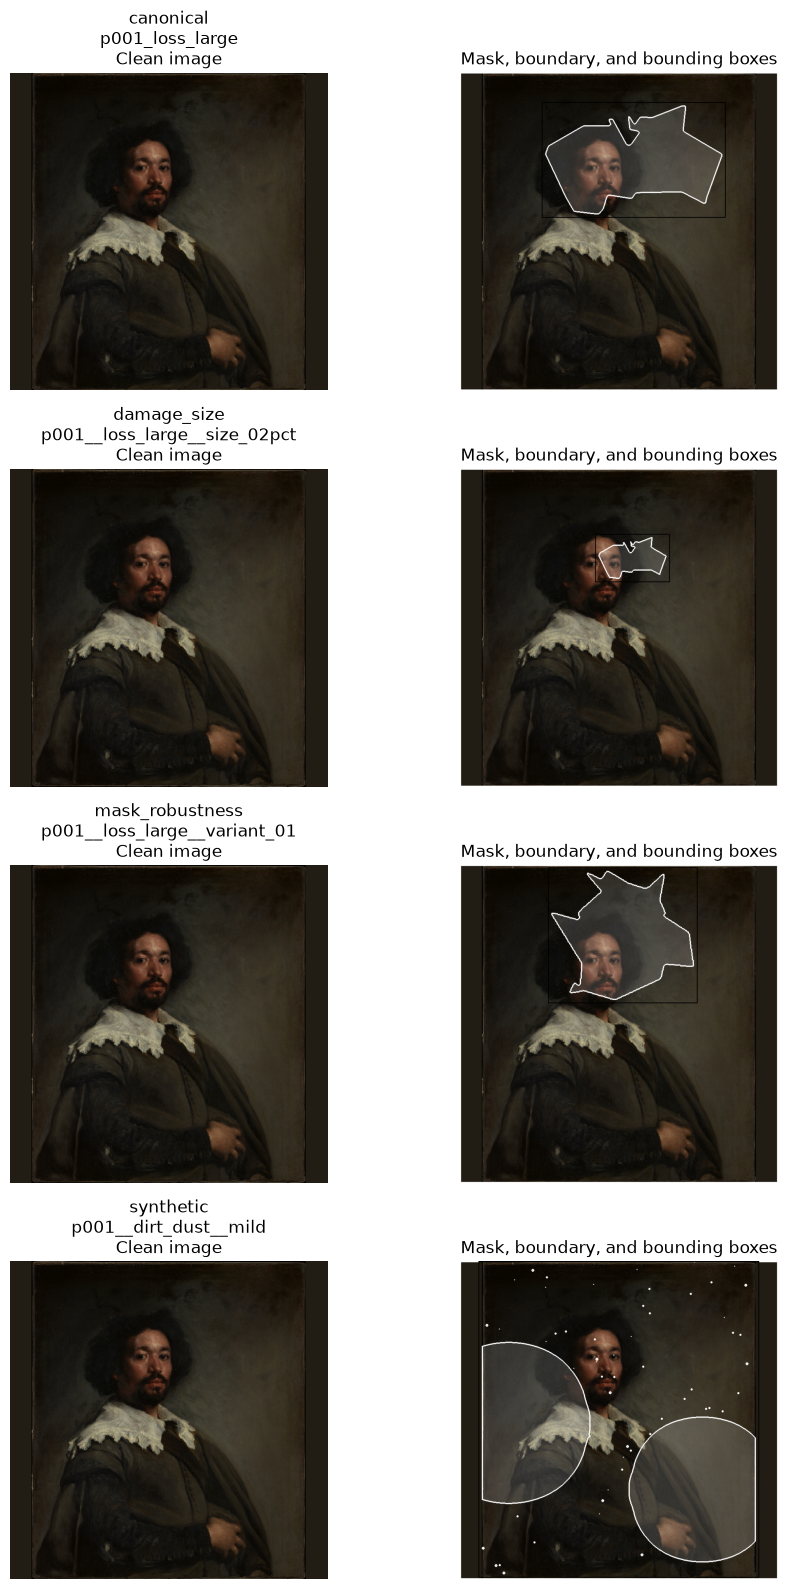

Geometry and corrected RGB-display validation passed for one case from each dataset.


In [57]:
def prepare_rgb_for_display(rgb_image):
    """
    Convert an RGB array into a Matplotlib-safe display format.

    Float RGB arrays in the 0–255 range must not be passed
    directly to imshow(), which expects float RGB in 0–1.
    """
    image_array = np.asarray(rgb_image)

    if np.issubdtype(
        image_array.dtype,
        np.floating,
    ):
        if image_array.max() > 1.0:
            image_array = (
                image_array / 255.0
            )

        return np.clip(
            image_array,
            0.0,
            1.0,
        )

    return np.clip(
        image_array,
        0,
        255,
    ).astype(np.uint8)


geometry_validation_rows = []
geometry_preview_rows = []

for dataset_name in sorted(
    case_manifest_df[
        "dataset_name"
    ].unique()
):
    case_row = (
        case_manifest_df.loc[
            case_manifest_df[
                "dataset_name"
            ].eq(dataset_name)
        ]
        .sort_values("case_id")
        .iloc[0]
    )

    clean_image = load_rgb_array(
        case_row["clean_path"]
    )

    mask_bool = load_mask_bool(
        case_row["mask_path"]
    )

    image_height, image_width = (
        clean_image.shape[:2]
    )

    if mask_bool.shape != (
        image_height,
        image_width,
    ):
        raise ValueError(
            f"Shape mismatch for "
            f"{dataset_name}/{case_row['case_id']}: "
            f"image={clean_image.shape[:2]}, "
            f"mask={mask_bool.shape}"
        )

    content_bbox, content_bbox_source = (
        extract_content_bbox(
            case_row,
            image_width=image_width,
            image_height=image_height,
        )
    )

    mask_bbox = bbox_from_binary_mask(
        mask_bool,
        margin=mask_bbox_margin,
    )

    mask_boundary = binary_mask_boundary(
        mask_bool,
        width=boundary_width,
    )

    overlay_image = create_spatial_overlay(
        clean_image,
        mask_bool,
        content_bbox=content_bbox,
        mask_bbox=mask_bbox,
        mask_alpha=0.15,
        boundary_width=boundary_width,
    )

    geometry_validation_rows.append(
        {
            "dataset_name": dataset_name,
            "case_id": case_row["case_id"],
            "image_height": image_height,
            "image_width": image_width,
            "image_dtype": str(
                clean_image.dtype
            ),
            "image_min": float(
                clean_image.min()
            ),
            "image_max": float(
                clean_image.max()
            ),
            "mask_pixels": int(
                mask_bool.sum()
            ),
            "boundary_pixels": int(
                mask_boundary.sum()
            ),
            "content_bbox": content_bbox,
            "content_bbox_source": (
                content_bbox_source
            ),
            "mask_bbox": mask_bbox,
        }
    )

    geometry_preview_rows.append(
        {
            "dataset_name": dataset_name,
            "case_id": case_row["case_id"],
            "clean_image": (
                prepare_rgb_for_display(
                    clean_image
                )
            ),
            "overlay_image": (
                prepare_rgb_for_display(
                    overlay_image
                )
            ),
        }
    )


geometry_validation_df = pd.DataFrame(
    geometry_validation_rows
)

display(
    geometry_validation_df
)

if geometry_validation_df[
    "mask_pixels"
].le(0).any():
    raise ValueError(
        "At least one validation mask contains no "
        "positive pixels."
    )

if geometry_validation_df[
    "boundary_pixels"
].le(0).any():
    raise ValueError(
        "At least one validation mask produced an "
        "empty boundary."
    )


figure, axes = plt.subplots(
    nrows=len(geometry_preview_rows),
    ncols=2,
    figsize=(
        10,
        4 * len(geometry_preview_rows),
    ),
    squeeze=False,
)

for row_index, preview_row in enumerate(
    geometry_preview_rows
):
    axes[row_index, 0].imshow(
        preview_row["clean_image"]
    )

    axes[row_index, 0].set_title(
        f"{preview_row['dataset_name']}\n"
        f"{preview_row['case_id']}\n"
        "Clean image"
    )

    axes[row_index, 1].imshow(
        preview_row["overlay_image"]
    )

    axes[row_index, 1].set_title(
        "Mask, boundary, and bounding boxes"
    )

    for axis in axes[row_index]:
        axis.axis("off")

figure.tight_layout()

plt.show()

print(
    "Geometry and corrected RGB-display validation "
    "passed for one case from each dataset."
)

In [59]:
max_scale_samples_per_case = 5_000
scale_rng = np.random.default_rng(42)

error_map_summary_rows = []

damaged_error_scale_samples = []
restored_error_scale_samples = []
signed_improvement_scale_samples = []

for row_number, (_, case_row) in enumerate(
    case_manifest_df.iterrows(),
    start=1,
):
    clean_image = load_rgb_array(
        case_row["clean_path"]
    )

    damaged_image = load_rgb_array(
        case_row["damaged_path"]
    )

    restored_image = load_rgb_array(
        case_row["restored_path"]
    )

    mask_bool = load_mask_bool(
        case_row["mask_path"]
    )

    if (
        clean_image.shape != damaged_image.shape
        or clean_image.shape != restored_image.shape
    ):
        raise ValueError(
            "Image shape mismatch for "
            f"{case_row['dataset_name']}/"
            f"{case_row['case_id']}: "
            f"clean={clean_image.shape}, "
            f"damaged={damaged_image.shape}, "
            f"restored={restored_image.shape}"
        )

    if mask_bool.shape != clean_image.shape[:2]:
        raise ValueError(
            "Mask shape mismatch for "
            f"{case_row['dataset_name']}/"
            f"{case_row['case_id']}: "
            f"mask={mask_bool.shape}, "
            f"image={clean_image.shape[:2]}"
        )

    damaged_error_map = compute_absolute_error_map(
        clean_arr=clean_image,
        candidate_arr=damaged_image,
    )

    restored_error_map = compute_absolute_error_map(
        clean_arr=clean_image,
        candidate_arr=restored_image,
    )

    signed_improvement_map = (
        compute_signed_improvement_map(
            damaged_error_map=damaged_error_map,
            restored_error_map=restored_error_map,
        )
    )

    masked_pixel_count = int(
        mask_bool.sum()
    )

    if masked_pixel_count > 0:
        damaged_masked_values = (
            damaged_error_map[mask_bool]
        )

        restored_masked_values = (
            restored_error_map[mask_bool]
        )

        improvement_masked_values = (
            signed_improvement_map[mask_bool]
        )

        sample_size = min(
            max_scale_samples_per_case,
            masked_pixel_count,
        )

        if sample_size < masked_pixel_count:
            sample_indices = scale_rng.choice(
                masked_pixel_count,
                size=sample_size,
                replace=False,
            )

            damaged_error_scale_samples.append(
                damaged_masked_values[
                    sample_indices
                ]
            )

            restored_error_scale_samples.append(
                restored_masked_values[
                    sample_indices
                ]
            )

            signed_improvement_scale_samples.append(
                improvement_masked_values[
                    sample_indices
                ]
            )

        else:
            damaged_error_scale_samples.append(
                damaged_masked_values
            )

            restored_error_scale_samples.append(
                restored_masked_values
            )

            signed_improvement_scale_samples.append(
                improvement_masked_values
            )

        damaged_error_mean_masked = float(
            damaged_masked_values.mean()
        )

        restored_error_mean_masked = float(
            restored_masked_values.mean()
        )

        improvement_mean_masked = float(
            improvement_masked_values.mean()
        )

        improvement_std_masked = float(
            improvement_masked_values.std()
        )

        negative_pixels_masked = int(
            (
                improvement_masked_values < 0
            ).sum()
        )

        positive_pixels_masked = int(
            (
                improvement_masked_values > 0
            ).sum()
        )

        zero_pixels_masked = int(
            (
                improvement_masked_values == 0
            ).sum()
        )

    else:
        damaged_error_mean_masked = np.nan
        restored_error_mean_masked = np.nan
        improvement_mean_masked = np.nan
        improvement_std_masked = np.nan

        negative_pixels_masked = 0
        positive_pixels_masked = 0
        zero_pixels_masked = 0

    error_map_summary_rows.append(
        {
            "dataset_name": (
                case_row["dataset_name"]
            ),
            "case_id": case_row["case_id"],
            "painting_id": (
                case_row["painting_id"]
            ),
            "mask_id": case_row.get(
                "mask_id",
                pd.NA,
            ),
            "mask_type": case_row.get(
                "mask_type",
                pd.NA,
            ),
            "category": case_row.get(
                "category",
                pd.NA,
            ),
            "model_name": (
                case_row["model_name"]
            ),
            "full_pixel_count": int(
                mask_bool.size
            ),
            "masked_pixel_count": (
                masked_pixel_count
            ),
            "damaged_error_mean_full": float(
                damaged_error_map.mean()
            ),
            "restored_error_mean_full": float(
                restored_error_map.mean()
            ),
            "improvement_mean_full": float(
                signed_improvement_map.mean()
            ),
            "damaged_error_max_full": float(
                damaged_error_map.max()
            ),
            "restored_error_max_full": float(
                restored_error_map.max()
            ),
            "improvement_min_full": float(
                signed_improvement_map.min()
            ),
            "improvement_max_full": float(
                signed_improvement_map.max()
            ),
            "damaged_error_mean_masked": (
                damaged_error_mean_masked
            ),
            "restored_error_mean_masked": (
                restored_error_mean_masked
            ),
            "improvement_mean_masked": (
                improvement_mean_masked
            ),
            "improvement_std_masked": (
                improvement_std_masked
            ),
            "negative_improvement_pixels_masked": (
                negative_pixels_masked
            ),
            "positive_improvement_pixels_masked": (
                positive_pixels_masked
            ),
            "zero_improvement_pixels_masked": (
                zero_pixels_masked
            ),
            "negative_improvement_percentage_masked": (
                (
                    100.0
                    * negative_pixels_masked
                    / masked_pixel_count
                )
                if masked_pixel_count > 0
                else np.nan
            ),
            "positive_improvement_percentage_masked": (
                (
                    100.0
                    * positive_pixels_masked
                    / masked_pixel_count
                )
                if masked_pixel_count > 0
                else np.nan
            ),
        }
    )

    if (
        row_number % 50 == 0
        or row_number == len(case_manifest_df)
    ):
        print(
            f"Processed "
            f"{row_number:,}/"
            f"{len(case_manifest_df):,} cases"
        )


error_map_summary_df = pd.DataFrame(
    error_map_summary_rows
)

print(
    "\nCompleted spatial-map statistics for "
    f"{len(error_map_summary_df):,} cases."
)

Processed 50/410 cases
Processed 100/410 cases
Processed 150/410 cases
Processed 200/410 cases
Processed 250/410 cases
Processed 300/410 cases
Processed 350/410 cases
Processed 400/410 cases
Processed 410/410 cases

Completed spatial-map statistics for 410 cases.


In [60]:
if not damaged_error_scale_samples:
    raise ValueError(
        "No non-empty masks were available for "
        "visualization-scale estimation."
    )

sampled_damaged_errors = np.concatenate(
    damaged_error_scale_samples
).astype(
    np.float32,
    copy=False,
)

sampled_restored_errors = np.concatenate(
    restored_error_scale_samples
).astype(
    np.float32,
    copy=False,
)

sampled_signed_improvements = np.concatenate(
    signed_improvement_scale_samples
).astype(
    np.float32,
    copy=False,
)

combined_absolute_error_samples = np.concatenate(
    [
        sampled_damaged_errors,
        sampled_restored_errors,
    ]
)

absolute_error_vmin = 0.0

absolute_error_vmax = float(
    np.percentile(
        combined_absolute_error_samples,
        99.5,
    )
)

signed_improvement_abs_limit = float(
    np.percentile(
        np.abs(
            sampled_signed_improvements
        ),
        99.5,
    )
)

signed_improvement_vmin = (
    -signed_improvement_abs_limit
)

signed_improvement_vmax = (
    signed_improvement_abs_limit
)

if not np.isfinite(
    absolute_error_vmax
):
    raise ValueError(
        "Absolute-error scale is not finite."
    )

if absolute_error_vmax <= 0:
    raise ValueError(
        "Absolute-error upper limit must be positive."
    )

if not np.isfinite(
    signed_improvement_abs_limit
):
    raise ValueError(
        "Signed-improvement scale is not finite."
    )

if signed_improvement_abs_limit <= 0:
    raise ValueError(
        "Signed-improvement limit must be positive."
    )

visualization_scale_df = pd.DataFrame(
    [
        {
            "map_type": "absolute_error",
            "vmin": absolute_error_vmin,
            "vmax": absolute_error_vmax,
            "percentile_policy": "masked_pixels_99.5",
            "sample_count": len(
                combined_absolute_error_samples
            ),
        },
        {
            "map_type": "signed_improvement",
            "vmin": signed_improvement_vmin,
            "vmax": signed_improvement_vmax,
            "percentile_policy": (
                "masked_absolute_values_99.5"
            ),
            "sample_count": len(
                sampled_signed_improvements
            ),
        },
    ]
)

display(
    visualization_scale_df
)

print(
    "Shared absolute-error scale:",
    (
        absolute_error_vmin,
        absolute_error_vmax,
    ),
)

print(
    "Shared signed-improvement scale:",
    (
        signed_improvement_vmin,
        signed_improvement_vmax,
    ),
)

,map_type,vmin,vmax,percentile_policy,sample_count
0,absolute_error,0.0,255.0,masked_pixels_99.5,3600000
1,signed_improvement,-253.0,253.0,masked_absolute_values_99.5,1800000


Shared absolute-error scale: (0.0, 255.0)
Shared signed-improvement scale: (-253.0, 253.0)


In [61]:
expected_summary_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "full_pixel_count",
    "masked_pixel_count",
    "damaged_error_mean_full",
    "restored_error_mean_full",
    "improvement_mean_full",
    "damaged_error_mean_masked",
    "restored_error_mean_masked",
    "improvement_mean_masked",
    "negative_improvement_percentage_masked",
    "positive_improvement_percentage_masked",
]

missing_summary_columns = [
    column
    for column in expected_summary_columns
    if column not in error_map_summary_df.columns
]

if missing_summary_columns:
    raise ValueError(
        "Error-map summary is missing columns: "
        f"{missing_summary_columns}"
    )

if len(error_map_summary_df) != len(
    case_manifest_df
):
    raise ValueError(
        "Error-map summary row count mismatch.\n"
        f"Expected: {len(case_manifest_df):,}\n"
        f"Observed: {len(error_map_summary_df):,}"
    )

if error_map_summary_df.duplicated(
    subset=[
        "dataset_name",
        "case_id",
    ]
).any():
    raise ValueError(
        "Duplicate dataset-case keys exist in the "
        "error-map summary."
    )

finite_columns = [
    "damaged_error_mean_full",
    "restored_error_mean_full",
    "improvement_mean_full",
    "damaged_error_max_full",
    "restored_error_max_full",
    "improvement_min_full",
    "improvement_max_full",
]

non_finite_counts = {}

for column in finite_columns:
    non_finite_count = int(
        (
            ~np.isfinite(
                error_map_summary_df[
                    column
                ].astype(float)
            )
        ).sum()
    )

    if non_finite_count > 0:
        non_finite_counts[
            column
        ] = non_finite_count

if non_finite_counts:
    raise ValueError(
        "Non-finite full-image summary values detected: "
        f"{non_finite_counts}"
    )

summary_validation_df = (
    error_map_summary_df
    .groupby(
        "dataset_name",
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "nunique",
        ),
        non_empty_masks=(
            "masked_pixel_count",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        zero_masks=(
            "masked_pixel_count",
            lambda values: int(
                (values == 0).sum()
            ),
        ),
        mean_damaged_error_masked=(
            "damaged_error_mean_masked",
            "mean",
        ),
        mean_restored_error_masked=(
            "restored_error_mean_masked",
            "mean",
        ),
        mean_improvement_masked=(
            "improvement_mean_masked",
            "mean",
        ),
        mean_positive_pixel_percentage=(
            "positive_improvement_percentage_masked",
            "mean",
        ),
    )
)

display(
    summary_validation_df
)

display(
    error_map_summary_df.head()
)

print(
    "Error-map summary validation passed for "
    f"{len(error_map_summary_df):,} cases."
)

,dataset_name,cases,non_empty_masks,zero_masks,mean_damaged_error_masked,mean_restored_error_masked,mean_improvement_masked,mean_positive_pixel_percentage
0,canonical,250,200,50,153.774082,15.840487,137.933593,98.744304
1,damage_size,35,35,0,155.526399,17.433920,138.092478,99.322687
2,mask_robustness,75,75,0,169.103776,14.957781,154.145996,99.547794
3,synthetic,50,50,0,4.770798,6.824720,-2.053921,5.042161


,dataset_name,case_id,painting_id,mask_id,mask_type,category,model_name,full_pixel_count,masked_pixel_count,damaged_error_mean_full,...,improvement_max_full,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,improvement_std_masked,negative_improvement_pixels_masked,positive_improvement_pixels_masked,zero_improvement_pixels_masked,negative_improvement_percentage_masked,positive_improvement_percentage_masked
0,canonical,p001_loss_large,p001,NaN,NaN,portrait_figure,opencv_telea,589824,69018,25.746441,...,248.000000,220.027664,11.091885,208.935776,31.118332,26,68991,1,0.037671,99.96088
1,canonical,p001_loss_small,p001,NaN,NaN,portrait_figure,opencv_telea,589824,18239,7.188738,...,247.000000,232.473816,4.542318,227.931503,18.350504,0,18239,0,0.000000,100.00000
2,canonical,p001_mixed_damage,p001,NaN,NaN,portrait_figure,opencv_telea,589824,45733,17.357267,...,254.333328,223.858749,13.331175,210.527588,34.033524,0,45733,0,0.000000,100.00000
3,canonical,p001_scratch_thin,p001,NaN,NaN,portrait_figure,opencv_telea,589824,12058,4.526926,...,253.000000,221.437164,4.254354,217.182800,28.250826,0,12058,0,0.000000,100.00000
4,canonical,p001_zero_control,p001,NaN,NaN,portrait_figure,opencv_telea,589824,0,0.000000,...,0.000000,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN


Error-map summary validation passed for 410 cases.


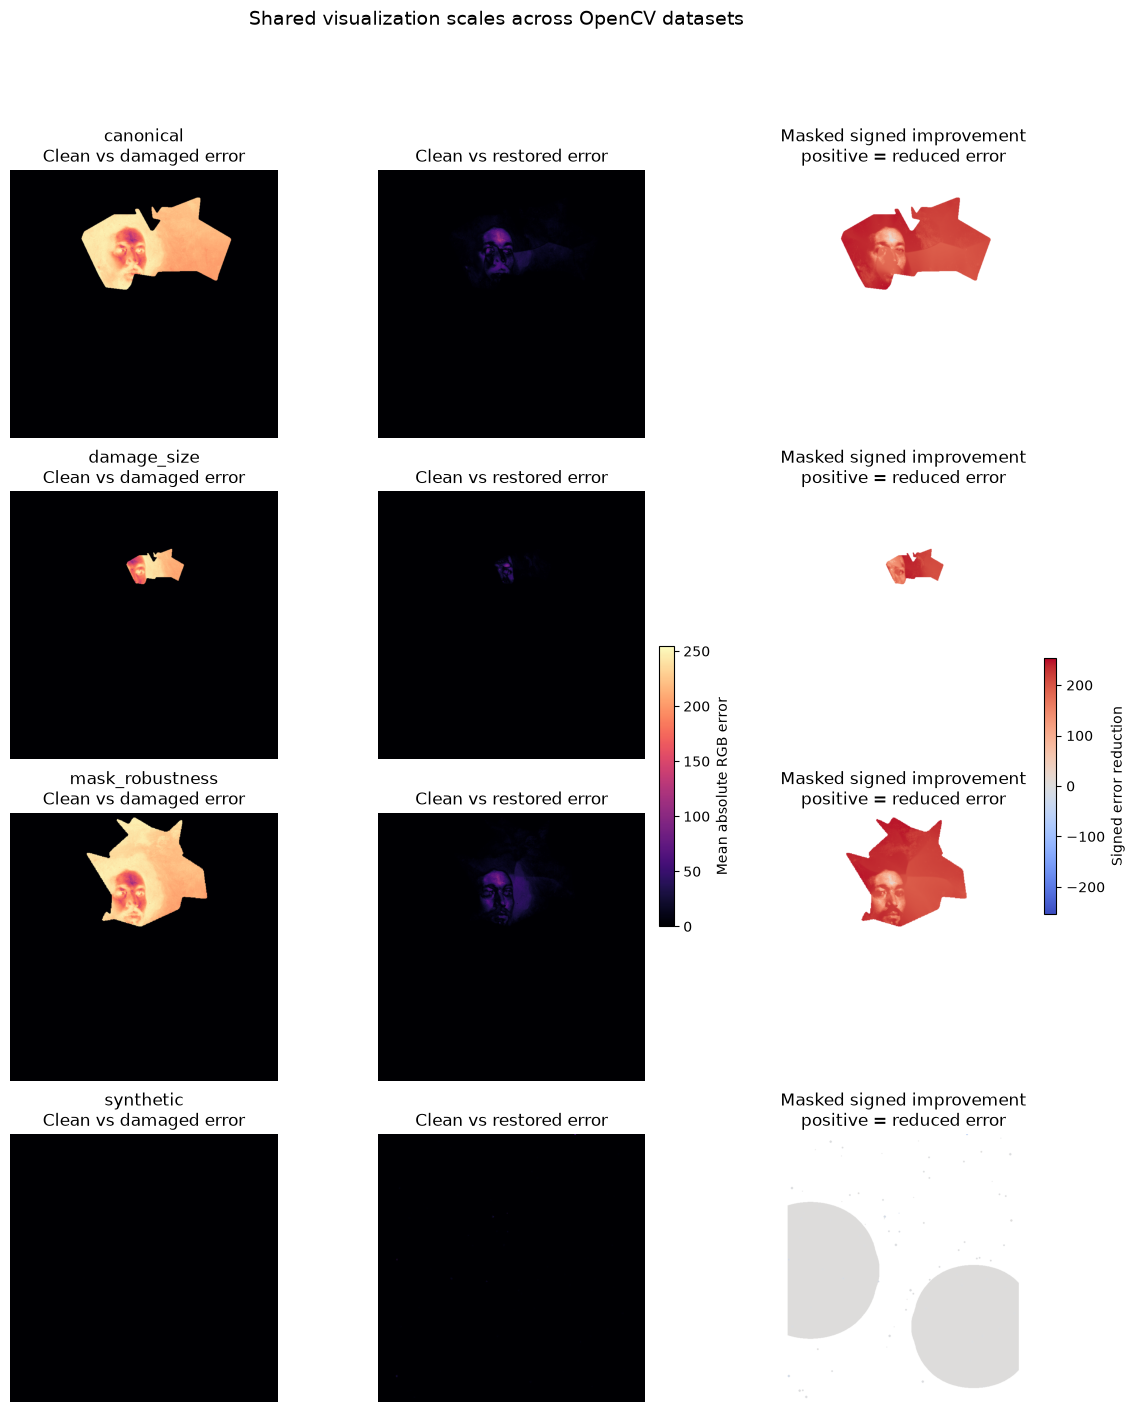

Shared-scale preview completed.


In [62]:
preview_case_rows = []

for dataset_name in sorted(
    case_manifest_df[
        "dataset_name"
    ].unique()
):
    dataset_cases = case_manifest_df.loc[
        case_manifest_df[
            "dataset_name"
        ].eq(dataset_name)
    ]

    non_zero_cases = dataset_cases.loc[
        dataset_cases["case_id"].isin(
            error_map_summary_df.loc[
                (
                    error_map_summary_df[
                        "dataset_name"
                    ].eq(dataset_name)
                )
                & (
                    error_map_summary_df[
                        "masked_pixel_count"
                    ].gt(0)
                ),
                "case_id",
            ]
        )
    ]

    if non_zero_cases.empty:
        continue

    preview_case_rows.append(
        non_zero_cases
        .sort_values("case_id")
        .iloc[0]
    )


figure, axes = plt.subplots(
    nrows=len(preview_case_rows),
    ncols=3,
    figsize=(
        14,
        4 * len(preview_case_rows),
    ),
    squeeze=False,
)

for row_index, case_row in enumerate(
    preview_case_rows
):
    clean_image = load_rgb_array(
        case_row["clean_path"]
    )

    damaged_image = load_rgb_array(
        case_row["damaged_path"]
    )

    restored_image = load_rgb_array(
        case_row["restored_path"]
    )

    mask_bool = load_mask_bool(
        case_row["mask_path"]
    )

    damaged_error_map = (
        compute_absolute_error_map(
            clean_arr=clean_image,
            candidate_arr=damaged_image,
        )
    )

    restored_error_map = (
        compute_absolute_error_map(
            clean_arr=clean_image,
            candidate_arr=restored_image,
        )
    )

    signed_improvement_map = (
        compute_signed_improvement_map(
            damaged_error_map=damaged_error_map,
            restored_error_map=restored_error_map,
        )
    )

    masked_signed_improvement_map = (
        apply_mask_to_map(
            signed_improvement_map,
            mask_bool,
            outside_value=np.nan,
        )
    )

    damaged_display = axes[
        row_index,
        0,
    ].imshow(
        damaged_error_map,
        cmap="magma",
        vmin=absolute_error_vmin,
        vmax=absolute_error_vmax,
    )

    restored_display = axes[
        row_index,
        1,
    ].imshow(
        restored_error_map,
        cmap="magma",
        vmin=absolute_error_vmin,
        vmax=absolute_error_vmax,
    )

    improvement_display = axes[
        row_index,
        2,
    ].imshow(
        masked_signed_improvement_map,
        cmap="coolwarm",
        vmin=signed_improvement_vmin,
        vmax=signed_improvement_vmax,
    )

    axes[row_index, 0].set_title(
        f"{case_row['dataset_name']}\n"
        "Clean vs damaged error"
    )

    axes[row_index, 1].set_title(
        "Clean vs restored error"
    )

    axes[row_index, 2].set_title(
        "Masked signed improvement\n"
        "positive = reduced error"
    )

    for axis in axes[row_index]:
        axis.axis("off")

figure.colorbar(
    damaged_display,
    ax=axes[:, 0:2].ravel().tolist(),
    fraction=0.02,
    pad=0.02,
    label="Mean absolute RGB error",
)

figure.colorbar(
    improvement_display,
    ax=axes[:, 2].ravel().tolist(),
    fraction=0.04,
    pad=0.02,
    label="Signed error reduction",
)

figure.suptitle(
    "Shared visualization scales across OpenCV datasets",
    fontsize=14,
)

plt.show()

print(
    "Shared-scale preview completed."
)

In [69]:
def create_opencv_case_diagnostic_figure(
    case_row,
    absolute_error_vmax,
    signed_improvement_abs_limit,
):
    """
    Create a standardized eight-panel OpenCV spatial
    diagnostic figure for one restoration case.

    Layout:
        1. Clean reference
        2. Damage mask with spatial overlays
        3. Damaged input
        4. OpenCV restored
        5. Clean vs damaged absolute error
        6. Clean vs restored absolute error
        7. Signed improvement
        8. Masked signed improvement
    """
    clean_image = load_rgb_array(
        case_row["clean_path"]
    )

    damaged_image = load_rgb_array(
        case_row["damaged_path"]
    )

    restored_image = load_rgb_array(
        case_row["restored_path"]
    )

    mask_bool = load_mask_bool(
        case_row["mask_path"]
    )

    if (
        clean_image.shape != damaged_image.shape
        or clean_image.shape != restored_image.shape
    ):
        raise ValueError(
            "Image shape mismatch for "
            f"{case_row['dataset_name']}/"
            f"{case_row['case_id']}."
        )

    if mask_bool.shape != clean_image.shape[:2]:
        raise ValueError(
            "Mask shape mismatch for "
            f"{case_row['dataset_name']}/"
            f"{case_row['case_id']}."
        )

    damaged_error_map = compute_absolute_error_map(
        clean_arr=clean_image,
        candidate_arr=damaged_image,
    )

    restored_error_map = compute_absolute_error_map(
        clean_arr=clean_image,
        candidate_arr=restored_image,
    )

    signed_improvement_map = (
        compute_signed_improvement_map(
            damaged_error_map=damaged_error_map,
            restored_error_map=restored_error_map,
        )
    )

    masked_signed_improvement_map = (
        apply_mask_to_map(
            signed_improvement_map,
            mask_bool,
            outside_value=np.nan,
        )
    )

    image_height, image_width = (
        clean_image.shape[:2]
    )

    content_bbox, content_bbox_source = (
        extract_content_bbox(
            case_row,
            image_width=image_width,
            image_height=image_height,
        )
    )

    mask_bbox = bbox_from_binary_mask(
        mask_bool,
        margin=mask_bbox_margin,
    )

    spatial_overlay = create_spatial_overlay(
        clean_image,
        mask_bool,
        content_bbox=content_bbox,
        mask_bbox=mask_bbox,
        mask_alpha=0.12,
        boundary_width=boundary_width,
    )

    figure = plt.figure(
        figsize=(18, 10),
        constrained_layout=True,
    )

    grid = figure.add_gridspec(
        nrows=3,
        ncols=4,
        height_ratios=[
            1.0,
            1.0,
            0.055,
        ],
    )

    axes = np.empty(
        shape=(2, 4),
        dtype=object,
    )

    for row_index in range(2):
        for column_index in range(4):
            axes[
                row_index,
                column_index,
            ] = figure.add_subplot(
                grid[
                    row_index,
                    column_index,
                ]
            )

    axes_flat = axes.ravel()

    absolute_colorbar_axis = (
        figure.add_subplot(
            grid[2, 0:2]
        )
    )

    signed_colorbar_axis = (
        figure.add_subplot(
            grid[2, 2:4]
        )
    )

    # --------------------------------------------------
    # Row 1: source and restoration images
    # --------------------------------------------------

    axes_flat[0].imshow(
        prepare_rgb_for_display(
            clean_image
        )
    )

    axes_flat[0].set_title(
        "Clean reference",
        fontsize=11,
    )

    axes_flat[1].imshow(
        prepare_rgb_for_display(
            spatial_overlay
        )
    )

    axes_flat[1].set_title(
        "Damage mask and spatial overlays",
        fontsize=11,
    )

    axes_flat[2].imshow(
        prepare_rgb_for_display(
            damaged_image
        )
    )

    axes_flat[2].set_title(
        "Damaged input",
        fontsize=11,
    )

    axes_flat[3].imshow(
        prepare_rgb_for_display(
            restored_image
        )
    )

    axes_flat[3].set_title(
        "OpenCV Telea restored",
        fontsize=11,
    )

    # --------------------------------------------------
    # Row 2: spatial diagnostic maps
    # --------------------------------------------------

    damaged_error_display = (
        axes_flat[4].imshow(
            damaged_error_map,
            cmap="magma",
            vmin=0.0,
            vmax=absolute_error_vmax,
        )
    )

    axes_flat[4].set_title(
        "Clean vs damaged\nabsolute error",
        fontsize=11,
    )

    axes_flat[5].imshow(
        restored_error_map,
        cmap="magma",
        vmin=0.0,
        vmax=absolute_error_vmax,
    )

    axes_flat[5].set_title(
        "Clean vs restored\nabsolute error",
        fontsize=11,
    )

    improvement_display = (
        axes_flat[6].imshow(
            signed_improvement_map,
            cmap="coolwarm",
            vmin=-signed_improvement_abs_limit,
            vmax=signed_improvement_abs_limit,
        )
    )

    axes_flat[6].set_title(
        "Signed improvement\n"
        "positive = reduced error",
        fontsize=11,
    )

    axes_flat[7].imshow(
        masked_signed_improvement_map,
        cmap="coolwarm",
        vmin=-signed_improvement_abs_limit,
        vmax=signed_improvement_abs_limit,
    )

    axes_flat[7].set_title(
        "Masked signed improvement\n"
        "positive = reduced error",
        fontsize=11,
    )

    for axis in axes_flat:
        axis.axis("off")

    # --------------------------------------------------
    # Dedicated horizontal colorbars
    # --------------------------------------------------

    absolute_colorbar = figure.colorbar(
        damaged_error_display,
        cax=absolute_colorbar_axis,
        orientation="horizontal",
    )

    absolute_colorbar.set_label(
        "Mean absolute RGB error",
        fontsize=10,
    )

    signed_colorbar = figure.colorbar(
        improvement_display,
        cax=signed_colorbar_axis,
        orientation="horizontal",
    )

    signed_colorbar.set_label(
        "Damaged error − restored error",
        fontsize=10,
    )

    # --------------------------------------------------
    # Figure-level title and annotation
    # --------------------------------------------------

    title_parts = [
        str(case_row["dataset_name"]),
        str(case_row["case_id"]),
        str(case_row["model_name"]),
    ]

    if (
        "mask_type" in case_row.index
        and pd.notna(case_row["mask_type"])
    ):
        title_parts.append(
            f"mask={case_row['mask_type']}"
        )

    if (
        "category" in case_row.index
        and pd.notna(case_row["category"])
    ):
        title_parts.append(
            f"category={case_row['category']}"
        )

    figure.suptitle(
        " | ".join(title_parts),
        fontsize=14,
        fontweight="semibold",
    )

    figure.supxlabel(
        (
            "Spatial overlay: translucent damage region, "
            "mask boundary, content bounding box, and "
            "mask bounding box. "
            f"Content-box source: {content_bbox_source}."
        ),
        fontsize=9,
    )

    return figure

In [70]:
representative_preview_rows = []

for dataset_name in sorted(
    case_manifest_df[
        "dataset_name"
    ].unique()
):
    dataset_summary_df = (
        error_map_summary_df.loc[
            (
                error_map_summary_df[
                    "dataset_name"
                ].eq(dataset_name)
            )
            & (
                error_map_summary_df[
                    "masked_pixel_count"
                ].gt(0)
            )
            & (
                error_map_summary_df[
                    "improvement_mean_masked"
                ].notna()
            )
        ]
        .copy()
    )

    if dataset_summary_df.empty:
        print(
            "No non-empty representative case for:",
            dataset_name,
        )

        continue

    median_improvement = float(
        dataset_summary_df[
            "improvement_mean_masked"
        ].median()
    )

    dataset_summary_df[
        "distance_from_median"
    ] = (
        dataset_summary_df[
            "improvement_mean_masked"
        ]
        - median_improvement
    ).abs()

    selected_summary_row = (
        dataset_summary_df
        .sort_values(
            [
                "distance_from_median",
                "case_id",
            ]
        )
        .iloc[0]
    )

    selected_case_df = (
        case_manifest_df.loc[
            (
                case_manifest_df[
                    "dataset_name"
                ].eq(dataset_name)
            )
            & (
                case_manifest_df[
                    "case_id"
                ].eq(
                    selected_summary_row[
                        "case_id"
                    ]
                )
            )
        ]
    )

    if len(selected_case_df) != 1:
        raise ValueError(
            "Representative case lookup failed for "
            f"{dataset_name}/"
            f"{selected_summary_row['case_id']}."
        )

    selected_case_row = (
        selected_case_df.iloc[0]
    )

    representative_preview_rows.append(
        selected_case_row
    )


representative_preview_df = pd.DataFrame(
    [
        {
            "dataset_name": row[
                "dataset_name"
            ],
            "case_id": row["case_id"],
            "painting_id": row[
                "painting_id"
            ],
            "mask_type": row.get(
                "mask_type",
                pd.NA,
            ),
            "category": row.get(
                "category",
                pd.NA,
            ),
        }
        for row in representative_preview_rows
    ]
)

display(
    representative_preview_df
)

,dataset_name,case_id,painting_id,mask_type,category
0,canonical,p037_loss_small,p037,NaN,abstraction_surrealism
1,damage_size,p018__loss_large__size_10pct,p018,NaN,landscape_natural
2,mask_robustness,p043__loss_small__variant_02,p043,NaN,high_texture_brushwork
3,synthetic,p018__water_stain__moderate,p018,NaN,landscape_natural


findfont: Failed to find font weight semibold, now using 700.


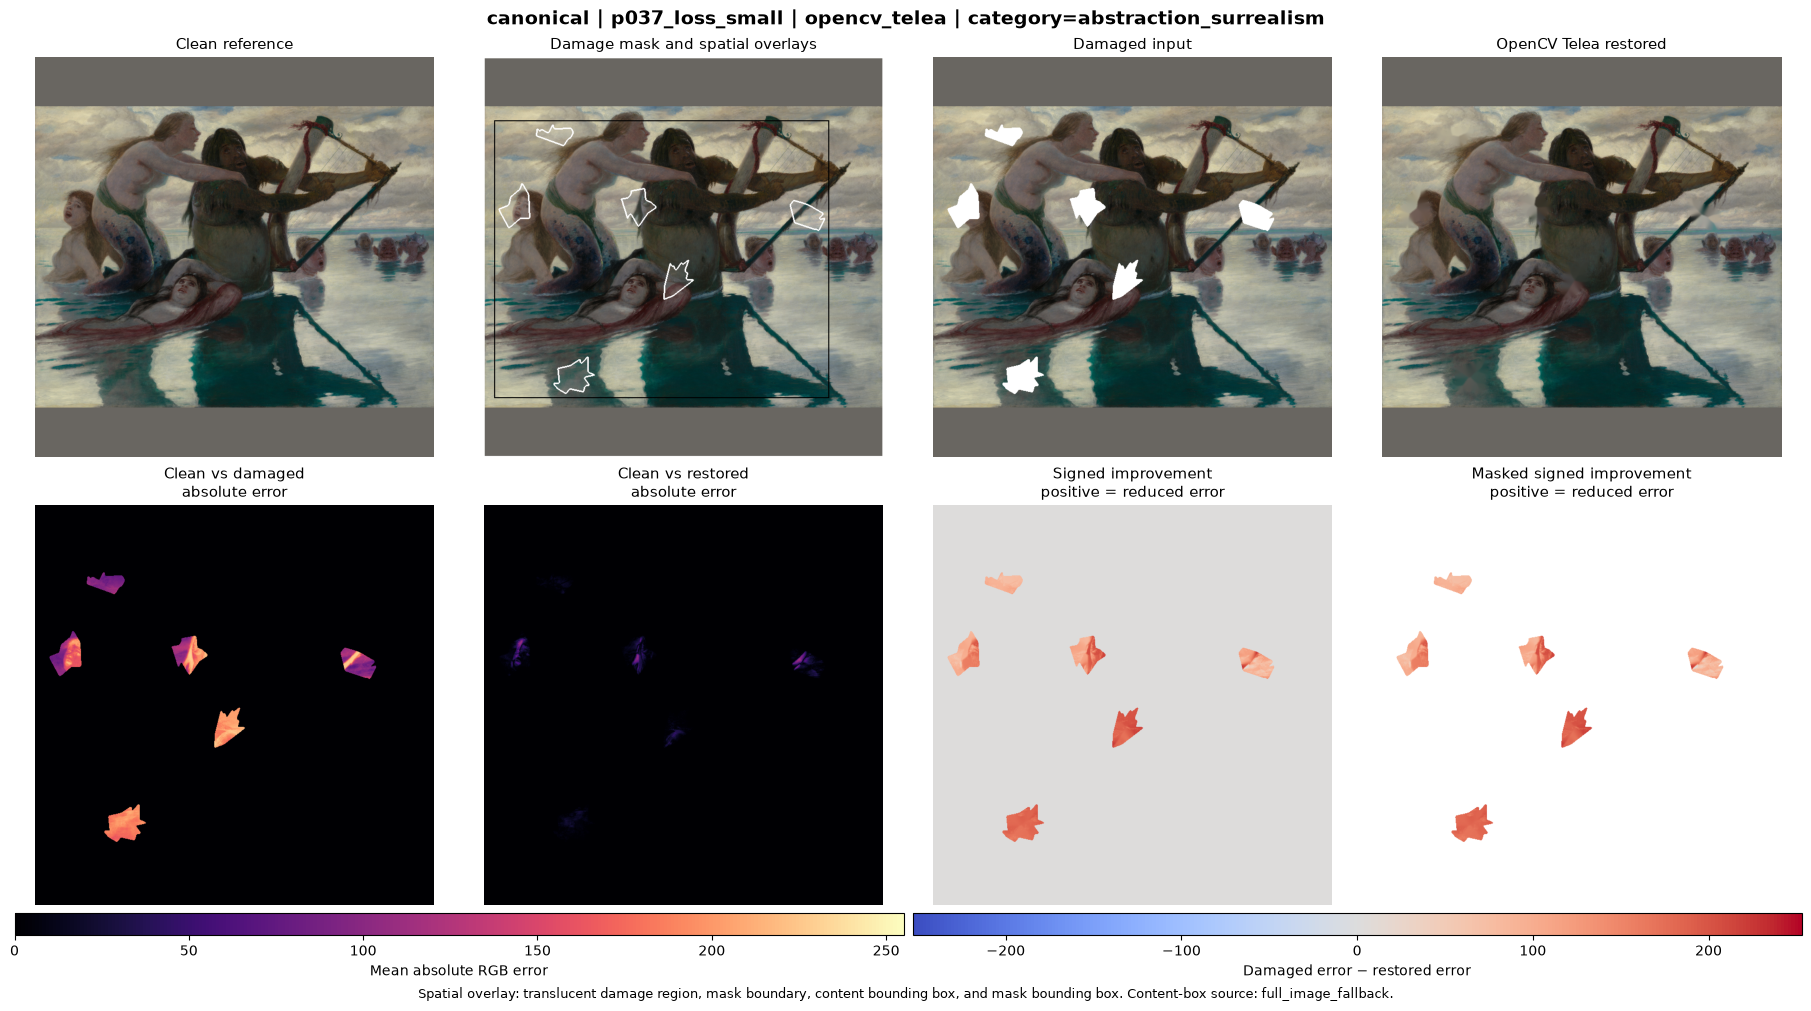

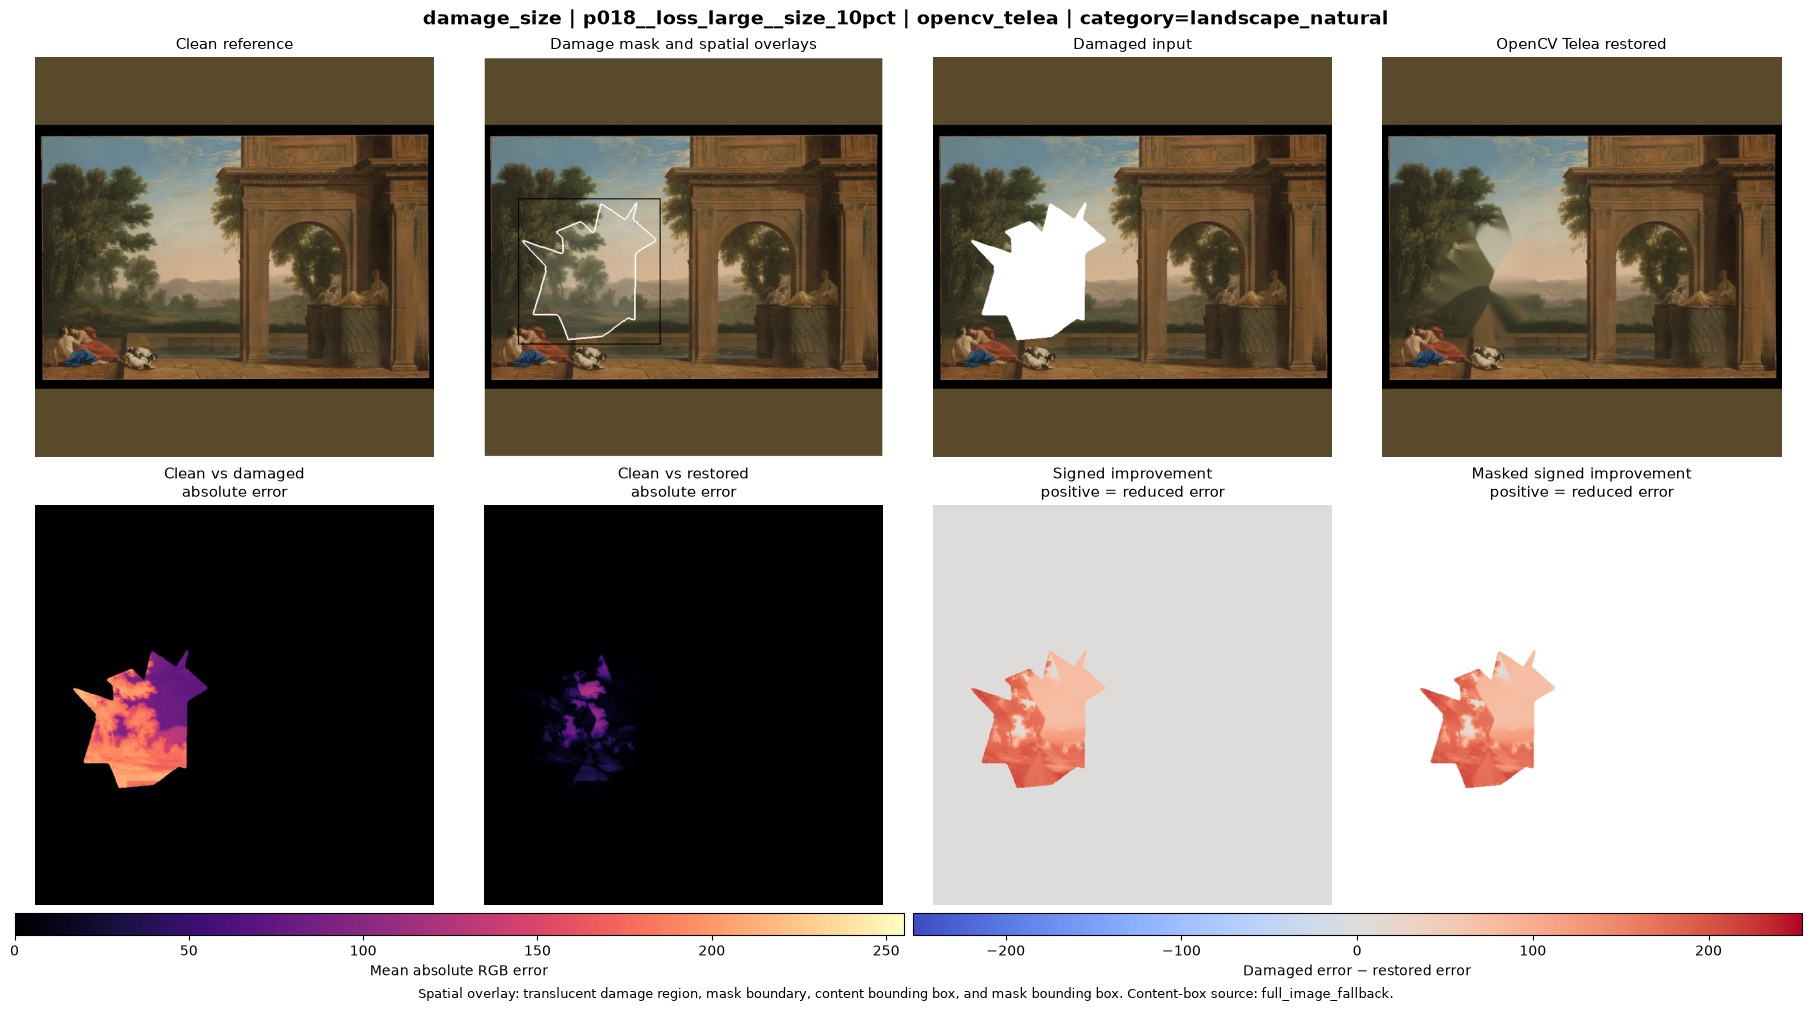

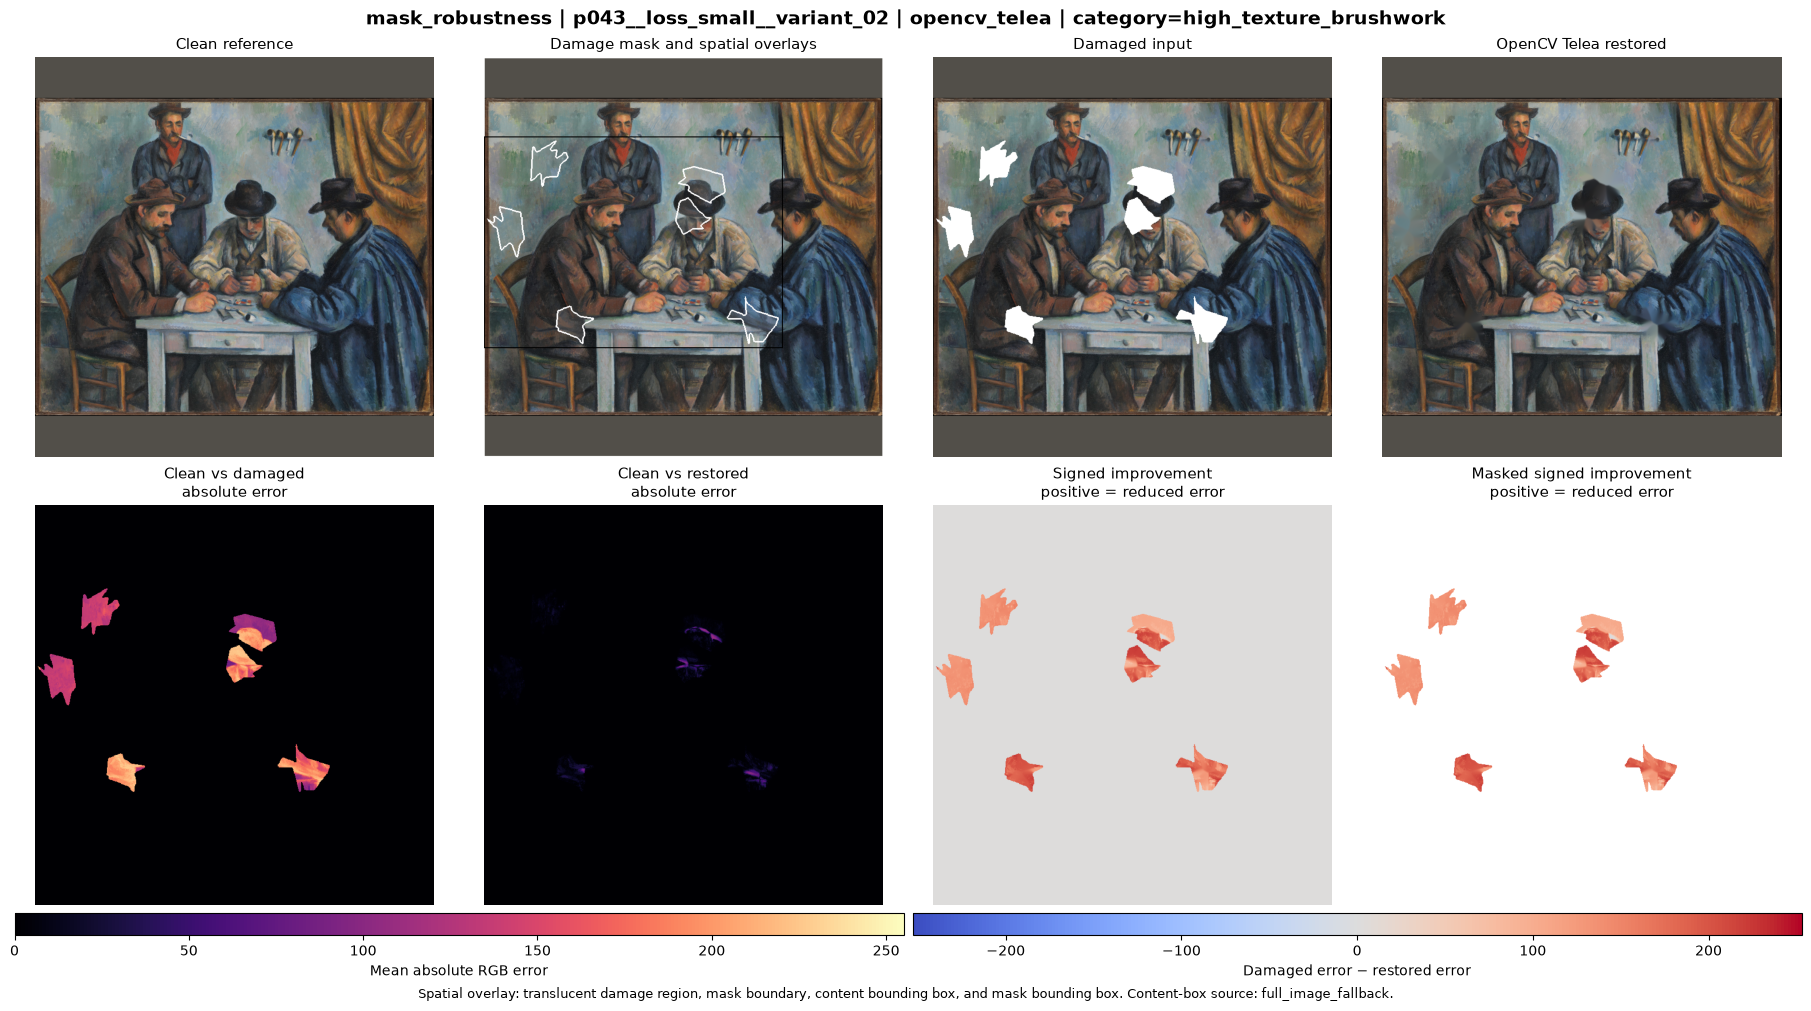

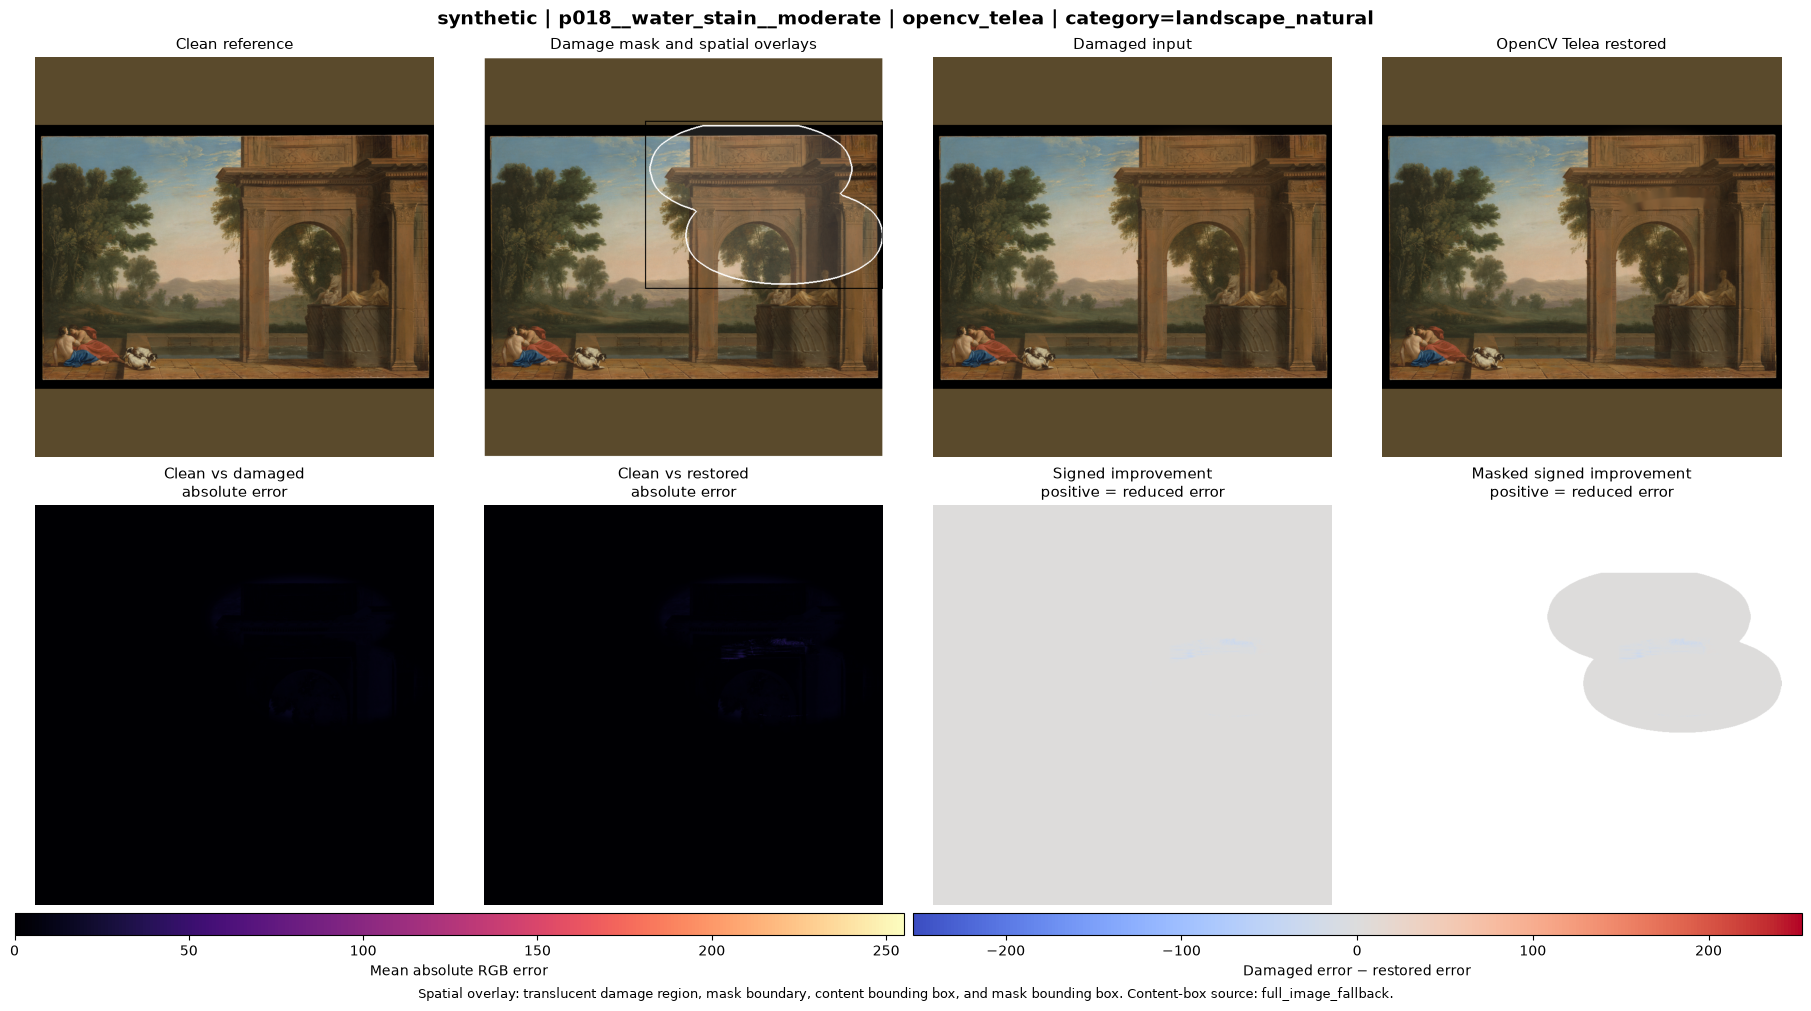

Eight-panel representative previews completed for all available OpenCV datasets.


In [71]:
for case_row in representative_preview_rows:

    diagnostic_figure = (
        create_opencv_case_diagnostic_figure(
            case_row=case_row,
            absolute_error_vmax=(
                absolute_error_vmax
            ),
            signed_improvement_abs_limit=(
                signed_improvement_abs_limit
            ),
        )
    )

    plt.show()

    plt.close(
        diagnostic_figure
    )

print(
    "Eight-panel representative previews completed "
    "for all available OpenCV datasets."
)

In [72]:
import re


difference_map_summary_path = (
    metrics_dir
    / "spatial_diagnostics_opencv_telea_all.csv"
)

visualization_scale_path = (
    metrics_dir
    / "spatial_diagnostic_scales_opencv_telea.csv"
)

figure_index_path = (
    metrics_dir
    / "spatial_diagnostic_figure_index_opencv_telea_all.csv"
)

overwrite_existing_figures = True
figure_dpi = 160


def safe_filename_component(value):
    """
    Convert an identifier into a filesystem-safe component.
    """
    text = str(value).strip()

    text = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        text,
    )

    text = text.strip(
        "._"
    )

    return text or "unnamed"


for dataset_name in sorted(
    case_manifest_df["dataset_name"].unique()
):
    dataset_output_dir = (
        error_map_output_dir
        / safe_filename_component(
            dataset_name
        )
    )

    dataset_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Figure root:", error_map_output_dir)
print("Summary table:", difference_map_summary_path)
print("Scale table:", visualization_scale_path)
print("Figure index:", figure_index_path)
print("Overwrite existing figures:", overwrite_existing_figures)
print("Figure DPI:", figure_dpi)

Figure root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\opencv_telea
Summary table: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostics_opencv_telea_all.csv
Scale table: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostic_scales_opencv_telea.csv
Figure index: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostic_figure_index_opencv_telea_all.csv
Overwrite existing figures: True
Figure DPI: 160


In [73]:
# Representative-only figure index.
# This replaces the earlier misleading "_all" filename.
figure_index_path = (
    metrics_dir
    / "spatial_diagnostic_figure_index_opencv_telea_representative.csv"
)

expected_dataset_counts = {
    "canonical": 250,
    "damage_size": 35,
    "mask_robustness": 75,
    "synthetic": 50,
}

expected_total_cases = sum(
    expected_dataset_counts.values()
)

required_summary_columns = {
    "dataset_name",
    "case_id",
    "painting_id",
    "improvement_mean_masked",
}

missing_summary_columns = (
    required_summary_columns
    - set(error_map_summary_df.columns)
)

if missing_summary_columns:
    raise ValueError(
        "Spatial-diagnostic summary is missing "
        "required columns:\n"
        f"{sorted(missing_summary_columns)}"
    )


summary_export_df = (
    error_map_summary_df
    .sort_values(
        [
            "dataset_name",
            "case_id",
        ]
    )
    .reset_index(drop=True)
)


if len(summary_export_df) != expected_total_cases:
    raise ValueError(
        "Unexpected number of spatial-diagnostic rows.\n"
        f"Expected: {expected_total_cases}\n"
        f"Observed: {len(summary_export_df)}"
    )


if summary_export_df.duplicated(
    subset=[
        "dataset_name",
        "case_id",
    ]
).any():
    duplicate_rows = (
        summary_export_df.loc[
            summary_export_df.duplicated(
                subset=[
                    "dataset_name",
                    "case_id",
                ],
                keep=False,
            )
        ]
        .sort_values(
            [
                "dataset_name",
                "case_id",
            ]
        )
    )

    display(
        duplicate_rows
    )

    raise ValueError(
        "Duplicate dataset/case keys exist in "
        "the spatial-diagnostic summary."
    )


observed_dataset_counts = (
    summary_export_df
    .groupby("dataset_name")
    .size()
    .to_dict()
)

if observed_dataset_counts != expected_dataset_counts:
    raise ValueError(
        "Dataset counts do not match the expected "
        "Notebook 10 scope.\n"
        f"Expected: {expected_dataset_counts}\n"
        f"Observed: {observed_dataset_counts}"
    )


summary_export_df.to_csv(
    difference_map_summary_path,
    index=False,
)

visualization_scale_df.to_csv(
    visualization_scale_path,
    index=False,
)


print(
    "Saved complete spatial-diagnostic summary:",
    difference_map_summary_path,
)

print(
    "Saved visualization scales:",
    visualization_scale_path,
)

print(
    "Summary rows:",
    len(summary_export_df),
)

print(
    "Dataset counts:",
    observed_dataset_counts,
)

Saved complete spatial-diagnostic summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostics_opencv_telea_all.csv
Saved visualization scales: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostic_scales_opencv_telea.csv
Summary rows: 410
Dataset counts: {'canonical': 250, 'damage_size': 35, 'mask_robustness': 75, 'synthetic': 50}


In [74]:
representative_selection_rows = []

selection_metric = (
    "improvement_mean_masked"
)


for dataset_name in expected_dataset_counts:
    dataset_summary_df = (
        summary_export_df.loc[
            summary_export_df[
                "dataset_name"
            ].eq(dataset_name)
        ]
        .dropna(
            subset=[
                selection_metric,
            ]
        )
        .sort_values(
            [
                selection_metric,
                "case_id",
            ],
            ascending=[
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    if len(dataset_summary_df) < 3:
        raise ValueError(
            "At least three valid cases are required "
            "for representative selection in dataset "
            f"{dataset_name!r}."
        )

    representative_positions = {
        "worst": 0,
        "median": len(dataset_summary_df) // 2,
        "best": len(dataset_summary_df) - 1,
    }

    for representative_role, row_position in (
        representative_positions.items()
    ):
        selected_row = (
            dataset_summary_df.iloc[
                row_position
            ]
        )

        representative_selection_rows.append(
            {
                "dataset_name": dataset_name,
                "case_id": selected_row[
                    "case_id"
                ],
                "painting_id": selected_row[
                    "painting_id"
                ],
                "representative_role": (
                    representative_role
                ),
                "selection_metric": (
                    selection_metric
                ),
                "selection_metric_value": (
                    selected_row[
                        selection_metric
                    ]
                ),
                "rank_position": (
                    row_position + 1
                ),
                "dataset_case_count": len(
                    dataset_summary_df
                ),
            }
        )


representative_selection_df = pd.DataFrame(
    representative_selection_rows
)


if len(representative_selection_df) != 12:
    raise ValueError(
        "Representative selection should contain "
        "exactly 12 cases."
    )


if representative_selection_df.duplicated(
    subset=[
        "dataset_name",
        "case_id",
    ]
).any():
    display(
        representative_selection_df
    )

    raise ValueError(
        "Representative selection contains "
        "duplicate dataset/case keys."
    )


representative_case_manifest_df = (
    representative_selection_df
    .merge(
        case_manifest_df,
        on=[
            "dataset_name",
            "case_id",
        ],
        how="left",
        validate="one_to_one",
        suffixes=(
            "_selection",
            "",
        ),
    )
)


required_manifest_paths = [
    "clean_path",
    "mask_path",
    "damaged_path",
    "restored_path",
]

missing_manifest_rows = (
    representative_case_manifest_df[
        required_manifest_paths
    ]
    .isna()
    .any(axis=1)
)

if missing_manifest_rows.any():
    display(
        representative_case_manifest_df.loc[
            missing_manifest_rows
        ]
    )

    raise ValueError(
        "One or more representative cases could "
        "not be matched to the case manifest."
    )


display_columns = [
    "dataset_name",
    "representative_role",
    "case_id",
    "painting_id",
    "selection_metric_value",
]

display(
    representative_case_manifest_df[
        display_columns
    ].sort_values(
        [
            "dataset_name",
            "selection_metric_value",
        ]
    )
)

,dataset_name,representative_role,case_id,painting_id,selection_metric_value
0,canonical,worst,p032_mixed_damage,p032,9.965009
1,canonical,median,p040_loss_small,p040,142.532669
2,canonical,best,p001_loss_small,p001,227.931503
3,damage_size,worst,p039__loss_large__size_15pct,p039,85.304108
4,damage_size,median,p018__loss_large__size_10pct,p018,129.553757
5,damage_size,best,p001__loss_large__size_15pct,p001,208.234573
6,mask_robustness,worst,p039__loss_large__variant_01,p039,79.016853
7,mask_robustness,median,p043__loss_small__variant_02,p043,151.779083
8,mask_robustness,best,p001__scratch_thin__variant_01,p001,230.480850
9,synthetic,worst,p039__partial_transparency__moderate,p039,-11.462428


In [75]:
representative_figure_rows = []
representative_generation_failures = []


for _, case_row in (
    representative_case_manifest_df
    .sort_values(
        [
            "dataset_name",
            "representative_role",
        ]
    )
    .iterrows()
):
    dataset_name = str(
        case_row["dataset_name"]
    )

    case_id = str(
        case_row["case_id"]
    )

    representative_role = str(
        case_row["representative_role"]
    )

    dataset_output_dir = (
        error_map_output_dir
        / safe_filename_component(
            dataset_name
        )
        / "representative"
    )

    dataset_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    figure_filename = (
        f"{safe_filename_component(dataset_name)}"
        f"__{safe_filename_component(representative_role)}"
        f"__{safe_filename_component(case_id)}"
        f"__opencv_telea_spatial_diagnostic.png"
    )

    figure_path = (
        dataset_output_dir
        / figure_filename
    )

    generation_status = "generated"

    try:
        if (
            figure_path.exists()
            and not overwrite_existing_figures
        ):
            generation_status = "existing"

        else:
            diagnostic_figure = (
                create_opencv_case_diagnostic_figure(
                    case_row=case_row,
                    absolute_error_vmax=(
                        absolute_error_vmax
                    ),
                    signed_improvement_abs_limit=(
                        signed_improvement_abs_limit
                    ),
                )
            )

            diagnostic_figure.savefig(
                figure_path,
                dpi=figure_dpi,
                bbox_inches="tight",
                facecolor="white",
            )

            plt.close(
                diagnostic_figure
            )

        representative_figure_rows.append(
            {
                "dataset_name": dataset_name,
                "case_id": case_id,
                "painting_id": case_row[
                    "painting_id"
                ],
                "representative_role": (
                    representative_role
                ),
                "selection_metric": (
                    case_row[
                        "selection_metric"
                    ]
                ),
                "selection_metric_value": (
                    case_row[
                        "selection_metric_value"
                    ]
                ),
                "model_name": case_row[
                    "model_name"
                ],
                "mask_type": case_row.get(
                    "mask_type",
                    pd.NA,
                ),
                "category": case_row.get(
                    "category",
                    pd.NA,
                ),
                "figure_path": str(
                    figure_path
                ),
                "generation_status": (
                    generation_status
                ),
                "figure_exists": (
                    figure_path.is_file()
                ),
                "figure_size_bytes": (
                    figure_path.stat().st_size
                    if figure_path.is_file()
                    else 0
                ),
            }
        )

    except Exception as error:
        plt.close("all")

        representative_generation_failures.append(
            {
                "dataset_name": dataset_name,
                "case_id": case_id,
                "representative_role": (
                    representative_role
                ),
                "error_type": type(
                    error
                ).__name__,
                "error_message": str(
                    error
                ),
            }
        )


representative_figure_index_df = pd.DataFrame(
    representative_figure_rows
)

representative_generation_failures_df = (
    pd.DataFrame(
        representative_generation_failures
    )
)


if not representative_generation_failures_df.empty:
    display(
        representative_generation_failures_df
    )

    raise RuntimeError(
        "One or more representative diagnostic "
        "figures could not be generated."
    )


representative_figure_index_df.to_csv(
    figure_index_path,
    index=False,
)


display(
    representative_figure_index_df[
        [
            "dataset_name",
            "representative_role",
            "case_id",
            "selection_metric_value",
            "generation_status",
            "figure_exists",
            "figure_size_bytes",
        ]
    ]
)


print(
    "Representative figures generated:",
    len(representative_figure_index_df),
)

print(
    "Figure index saved:",
    figure_index_path,
)

,dataset_name,representative_role,case_id,selection_metric_value,generation_status,figure_exists,figure_size_bytes
0,canonical,best,p001_loss_small,227.931503,generated,True,2018409
1,canonical,median,p040_loss_small,142.532669,generated,True,2567226
2,canonical,worst,p032_mixed_damage,9.965009,generated,True,2142574
3,damage_size,best,p001__loss_large__size_15pct,208.234573,generated,True,2177327
4,damage_size,median,p018__loss_large__size_10pct,129.553757,generated,True,1661050
5,damage_size,worst,p039__loss_large__size_15pct,85.304108,generated,True,2286182
6,mask_robustness,best,p001__scratch_thin__variant_01,230.480850,generated,True,1948214
7,mask_robustness,median,p043__loss_small__variant_02,151.779083,generated,True,2400280
8,mask_robustness,worst,p039__loss_large__variant_01,79.016853,generated,True,2251354
9,synthetic,best,p001__partial_transparency__severe,2.655432,generated,True,3203579


Representative figures generated: 12
Figure index saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostic_figure_index_opencv_telea_representative.csv


In [76]:
final_output_audit_rows = [
    {
        "output_name": (
            "complete_spatial_diagnostic_summary"
        ),
        "output_path": str(
            difference_map_summary_path
        ),
        "expected_rows": (
            expected_total_cases
        ),
        "observed_rows": len(
            summary_export_df
        ),
        "exists": (
            difference_map_summary_path
            .is_file()
        ),
        "file_size_bytes": (
            difference_map_summary_path
            .stat()
            .st_size
            if difference_map_summary_path
            .is_file()
            else 0
        ),
    },
    {
        "output_name": (
            "visualization_scales"
        ),
        "output_path": str(
            visualization_scale_path
        ),
        "expected_rows": len(
            visualization_scale_df
        ),
        "observed_rows": len(
            visualization_scale_df
        ),
        "exists": (
            visualization_scale_path
            .is_file()
        ),
        "file_size_bytes": (
            visualization_scale_path
            .stat()
            .st_size
            if visualization_scale_path
            .is_file()
            else 0
        ),
    },
    {
        "output_name": (
            "representative_figure_index"
        ),
        "output_path": str(
            figure_index_path
        ),
        "expected_rows": 12,
        "observed_rows": len(
            representative_figure_index_df
        ),
        "exists": (
            figure_index_path
            .is_file()
        ),
        "file_size_bytes": (
            figure_index_path
            .stat()
            .st_size
            if figure_index_path
            .is_file()
            else 0
        ),
    },
]


final_output_audit_df = pd.DataFrame(
    final_output_audit_rows
)

display(
    final_output_audit_df
)


if not final_output_audit_df[
    "exists"
].all():
    raise FileNotFoundError(
        "One or more final Notebook 10 output "
        "tables are missing."
    )


if final_output_audit_df[
    "file_size_bytes"
].le(0).any():
    raise ValueError(
        "One or more final Notebook 10 output "
        "tables are empty."
    )


if (
    final_output_audit_df[
        "expected_rows"
    ]
    != final_output_audit_df[
        "observed_rows"
    ]
).any():
    raise ValueError(
        "One or more final Notebook 10 output "
        "tables have an unexpected row count."
    )


if len(
    representative_figure_index_df
) != 12:
    raise ValueError(
        "Exactly 12 representative figures "
        "must be indexed."
    )


if not representative_figure_index_df[
    "figure_exists"
].all():
    missing_figures_df = (
        representative_figure_index_df.loc[
            ~representative_figure_index_df[
                "figure_exists"
            ]
        ]
    )

    display(
        missing_figures_df
    )

    raise FileNotFoundError(
        "One or more representative diagnostic "
        "figures are missing."
    )


if representative_figure_index_df[
    "figure_size_bytes"
].le(0).any():
    raise ValueError(
        "One or more representative diagnostic "
        "figures are empty."
    )


representative_counts_df = (
    representative_figure_index_df
    .groupby(
        [
            "dataset_name",
            "representative_role",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "figure_count",
        }
    )
)

display(
    representative_counts_df
)


print(
    "\nNotebook 10 complete."
)

print(
    "\nValidated:"
)

print(
    f"- {len(summary_export_df):,} "
    "case-level spatial-diagnostic rows"
)

print(
    "- 4 restoration datasets"
)

print(
    "- 1 shared absolute-error scale"
)

print(
    "- 1 shared signed-improvement scale"
)

print(
    "- 12 representative eight-panel figures"
)

print(
    "- Best, median, and worst case "
    "for each dataset"
)

print(
    "\nNo full 410-figure batch was generated."
)

print(
    "\nOutput tables:"
)

print(
    "-",
    difference_map_summary_path,
)

print(
    "-",
    visualization_scale_path,
)

print(
    "-",
    figure_index_path,
)

print(
    "\nRepresentative figure root:"
)

print(
    "-",
    error_map_output_dir,
)

,output_name,output_path,expected_rows,observed_rows,exists,file_size_bytes
0,complete_spatial_diagnostic_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,410,410,True,118269
1,visualization_scales,D:\Masters\FH\Thesis\painting-restoration-eval...,2,2,True,173
2,representative_figure_index,D:\Masters\FH\Thesis\painting-restoration-eval...,12,12,True,4370


,dataset_name,representative_role,figure_count
0,canonical,best,1
1,canonical,median,1
2,canonical,worst,1
3,damage_size,best,1
4,damage_size,median,1
5,damage_size,worst,1
6,mask_robustness,best,1
7,mask_robustness,median,1
8,mask_robustness,worst,1
9,synthetic,best,1



Notebook 10 complete.

Validated:
- 410 case-level spatial-diagnostic rows
- 4 restoration datasets
- 1 shared absolute-error scale
- 1 shared signed-improvement scale
- 12 representative eight-panel figures
- Best, median, and worst case for each dataset

No full 410-figure batch was generated.

Output tables:
- D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostics_opencv_telea_all.csv
- D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostic_scales_opencv_telea.csv
- D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\spatial_diagnostic_figure_index_opencv_telea_representative.csv

Representative figure root:
- D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\opencv_telea


## Notebook 10 Summary

This notebook generated spatial diagnostic outputs for all OpenCV Telea restoration cases across the four evaluation datasets:

- canonical
- damage size sensitivity
- mask robustness
- synthetic degradation

For each restoration case, the notebook computed:

- clean-versus-damaged absolute error
- clean-versus-restored absolute error
- signed improvement
- masked signed improvement
- masked-region summary statistics
- spatial metadata including content and mask bounding boxes

The notebook exported a complete case-level spatial diagnostics table covering all 410 restoration cases and saved shared visualization scales so that error-map comparisons remain consistent across datasets.

To avoid producing hundreds of largely redundant image files, eight-panel diagnostic figures were generated only for representative cases. For each dataset, the notebook selected:

- the case with the highest masked mean improvement
- the median-ranked case
- the case with the lowest masked mean improvement

This produced 12 representative figures in total. Each figure contains:

1. clean reference
2. damage mask and spatial overlays
3. damaged input
4. OpenCV Telea restoration
5. clean-versus-damaged absolute error
6. clean-versus-restored absolute error
7. signed improvement
8. masked signed improvement

The notebook therefore preserves complete quantitative coverage for all cases while using a compact, reproducible set of visual examples for reporting and thesis analysis.

### Main outputs

- `spatial_diagnostics_opencv_telea_all.csv`
- `spatial_diagnostic_scales_opencv_telea.csv`
- `spatial_diagnostic_figure_index_opencv_telea_representative.csv`
- 12 representative eight-panel spatial diagnostic figures

### Final scope

- 410 restoration cases evaluated
- 4 datasets covered
- 12 representative figures generated
- full per-case spatial diagnostics retained
- no unnecessary full export of 410 figures